## given isolated clusters of drifters, create contours of the watersheds and find the areas of the contours considering a spherical earth.

#### import and define clusters

In [132]:
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np
import geopandas as gpd
import os
from scipy.ndimage import gaussian_filter
from shapely.geometry import Polygon, MultiPolygon
import pyproj

In [133]:
os.chdir('/dat1/openonic/Drifters') # directory
beach_undrogued = pd.read_csv('undrogued_beach.csv')

In [134]:

os.chdir('/home/openonic/global-drifter-program/new/full_watersheds')
id_dataframes = {
    'W Indian': 'W_Indian_ids.csv',
    'W Pacific': 'W_Pacific_ids.csv',
    'Central Pacific': 'Central_Pacific_ids.csv',
    'SW Pacific': 'SW_Pacific_ids.csv',
    'NW Atlantic': 'NW_Atlantic_ids.csv',
    'SO SAmerica': 'Southern_Ocean_S_America_ids.csv', 
    'NE Atlantic': 'NE_Atlantic_ids.csv',
    'N Indian': 'N_Indian_ids.csv',    
    'SO Oceania': 'Southern_Ocean_Oceania_ids.csv', 
    'SW Atlantic': 'SW_Atlantic_ids.csv',
    'SE Atlantic': 'SE_Atlantic_ids.csv',
    'N Pacific': 'N_Pacific_ids.csv'
}

coord_dataframes = {
    'W Indian': 'W_Indian_coords.csv',
    'W Pacific': 'W_Pacific_coords.csv',
    'Central Pacific': 'Central_Pacific_coords.csv',
    'SW Pacific': 'SW_Pacific_coords.csv',
    'NW Atlantic': 'NW_Atlantic_coords.csv',
    'SO SAmerica': 'Southern_Ocean_S_America_coords.csv', 
    'NE Atlantic': 'NE_Atlantic_coords.csv',
    'N Indian': 'N_Indian_coords.csv',    
    'SO Oceania': 'Southern_Ocean_Oceania_coords.csv', 
    'SW Atlantic': 'SW_Atlantic_coords.csv',
    'SE Atlantic': 'SE_Atlantic_coords.csv',
    'N Pacific': 'N_Pacific_coords.csv'
}

loaded_ids = {k: pd.read_csv(v) for k, v in id_dataframes.items()}

for name in loaded_ids:
    ids_df = loaded_ids[name]

    # assumes the ID column is named 'id'
    ids = ids_df['0'].unique()

    coords = beach_undrogued[beach_undrogued['id'].isin(ids)].copy()

    coords.to_csv(coord_dataframes[name], index=False)

In [135]:
os.chdir('/home/openonic/global-drifter-program/new/full_watersheds')
dataframes = {
    'W Indian': 'W_Indian_coords.csv',
    'W Pacific': 'W_Pacific_coords.csv',
    'Central Pacific': 'Central_Pacific_coords.csv',
    'SW Pacific': 'SW_Pacific_coords.csv',
    'NW Atlantic': 'NW_Atlantic_coords.csv',
    'SO SAmerica': 'Southern_Ocean_S_America_coords.csv', 
    'NE Atlantic': 'NE_Atlantic_coords.csv',
    'N Indian': 'N_Indian_coords.csv',    
    'SO Oceania': 'Southern_Ocean_Oceania_coords.csv', 
    'SW Atlantic': 'SW_Atlantic_coords.csv',
    'SE Atlantic': 'SE_Atlantic_coords.csv',
    'N Pacific': 'N_Pacific_coords.csv'}

#### sort cluster trajectories into their time based groups using functions: 1 month, 3 months, 6 months, 1 year

In [136]:
def one_to_beach(cluster):
    
    # one month in seconds
    one = 2629800
    
    # if the trajectory is long enough (i.e, if the time in the trajectory is greater than 1 month,
    if (cluster['time_to_beach'] >= one).any():
        
        # append all times less than one month to the filtered cluster.
        filtered_cluster = cluster[cluster['time_to_beach'] <= one]
    return filtered_cluster

# repeat for the other time based groups

In [137]:
def three_to_beach(cluster):

    three = 7776000
    
    if (cluster['time_to_beach'] >= three).any():
        filtered_cluster = cluster[cluster['time_to_beach'] <= three]
    return filtered_cluster

In [138]:
def six_to_beach(cluster):

    six = 15638400
    
    if (cluster['time_to_beach'] >= six).any():
        filtered_cluster = cluster[cluster['time_to_beach'] <= six]
    return filtered_cluster

In [139]:
def year_to_beach(cluster):

    year = 31536000
    
    if (cluster['time_to_beach'] >= year).any():
        filtered_cluster = cluster[cluster['time_to_beach'] <= year]
    return filtered_cluster

#### define the times to beach (1yr, 6m, 3m, 1m) and dataframe

In [140]:
# define the grid cells
n_lons, n_lats = 135, 85

# define the bins
lon_bins = np.linspace(-180, 180, n_lons + 1)
lat_bins = np.linspace(-90, 90, n_lats + 1)

#dataframes = {
#    'S_Pacific_Islands': 'cluster_6_data.csv',    
#    'Indian_Ocean': 'cluster_14_data.csv',    
#    'SE_Pacific': 'cluster_0_data.csv',
#    'SW_SA': 'cluster_5_data.csv',
#    'Brazil': 'cluster_10_data.csv',    
#    'Europe': 'cluster_3_data.csv',
#    'Caribbean_Florida': 'cluster_12_data.csv',    
#    'Asia': 'cluster_16_data.csv',
#    'Alaska_Canada': 'cluster_7_data.csv'
#}

In [141]:
def preprocess_data(df):
    df['lat'] = pd.to_numeric(df['lat'], errors='coerce')
    df['lon'] = pd.to_numeric(df['lon'], errors='coerce')
    df.dropna(subset=['lat', 'lon'], inplace=True)

    return df

In [142]:
def year_area(cluster_file):
    data = pd.read_csv(cluster_file)
    data = year_to_beach(data)
    data = preprocess_data(data)

    latitudes = data['lat'].values
    longitudes = data['lon'].values
    heatmap_data, _, _ = np.histogram2d(latitudes, longitudes, bins=[lat_bins, lon_bins], density=False)

    fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(10, 6))

    lat_centers = (lat_bins[:-1] + lat_bins[1:]) / 2
    lon_centers = (lon_bins[:-1] + lon_bins[1:]) / 2
    mesh = ax.pcolormesh(lon_centers, lat_centers, heatmap_data, cmap='viridis', transform=ccrs.PlateCarree())

    contour = ax.contour(lon_centers, lat_centers, heatmap_data, levels=[100], colors='white', linestyles='solid', transform=ccrs.PlateCarree())

    total_area = 0
    for level_segments in contour.allsegs:
        for polygon_coords in level_segments:
            if len(polygon_coords) >= 3:
                polygon = Polygon(polygon_coords)
                
                # create a GeoDataFrame to handle projection and area calculation
                gdf = gpd.GeoDataFrame(index=[0], crs="EPSG:4326", geometry=[polygon])  # EPSG:4326 is lat/lon
                
                
                gdf = gdf.to_crs(epsg=6933)
                
                # add the area of the projected polygon (in square meters)
                total_area += gdf.geometry.area[0]
                
    total_area = total_area / 1_000_000  # 1,000,000 square meters in a square kilometer
    
    
    return total_area

In [143]:
def year_area(cluster_file):
    data = pd.read_csv(cluster_file)
    data = year_to_beach(data)
    data = preprocess_data(data)

    latitudes = data['lat'].values
    longitudes = data['lon'].values
    heatmap_data, _, _ = np.histogram2d(latitudes, longitudes, bins=[lat_bins, lon_bins], density=False)

    fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(10, 6))

    lat_centers = (lat_bins[:-1] + lat_bins[1:]) / 2
    lon_centers = (lon_bins[:-1] + lon_bins[1:]) / 2
    mesh = ax.pcolormesh(lon_centers, lat_centers, heatmap_data, cmap='viridis', transform=ccrs.PlateCarree())

    contour = ax.contour(lon_centers, lat_centers, heatmap_data, levels=[100], colors='white', linestyles='solid', transform=ccrs.PlateCarree())

    total_area = 0
    for level_segments in contour.allsegs:
        for polygon_coords in level_segments:
            if len(polygon_coords) >= 3:
                polygon = Polygon(polygon_coords)

                # Create a GeoDataFrame to handle projection and area calculation
                gdf = gpd.GeoDataFrame(index=[0], crs="EPSG:4326", geometry=[polygon])  # EPSG:4326 is lat/lon
                
                gdf = gdf.to_crs(epsg=6933)
                
                # Add the area of the projected polygon (in square meters)
                total_area += gdf.geometry.area[0]
                
    total_area = total_area / 1_000_000  # 1,000,000 square meters in a square kilometer
    
    return total_area


In [144]:
def six_area(cluster_file):
    data = pd.read_csv(cluster_file)
    data = six_to_beach(data)
    data = preprocess_data(data)

    latitudes = data['lat'].values
    longitudes = data['lon'].values
    heatmap_data, _, _ = np.histogram2d(latitudes, longitudes, bins=[lat_bins, lon_bins], density=False)

    fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(10, 6))

    lat_centers = (lat_bins[:-1] + lat_bins[1:]) / 2
    lon_centers = (lon_bins[:-1] + lon_bins[1:]) / 2
    mesh = ax.pcolormesh(lon_centers, lat_centers, heatmap_data, cmap='viridis', transform=ccrs.PlateCarree())

    contour = ax.contour(lon_centers, lat_centers, heatmap_data, levels=[100], colors='white', linestyles='solid', transform=ccrs.PlateCarree())

    total_area = 0
    for level_segments in contour.allsegs:
        for polygon_coords in level_segments:
            if len(polygon_coords) >= 3:
                polygon = Polygon(polygon_coords)
                
                # Create a GeoDataFrame to handle projection and area calculation
                gdf = gpd.GeoDataFrame(index=[0], crs="EPSG:4326", geometry=[polygon])  # EPSG:4326 is lat/lon
                
                gdf = gdf.to_crs(epsg=6933)
                
                # Add the area of the projected polygon (in square meters)
                total_area += gdf.geometry.area[0]
                
    total_area = total_area / 1_000_000  # 1,000,000 square meters in a square kilometer
    
    return total_area

In [145]:
def three_area(cluster_file):
    data = pd.read_csv(cluster_file)
    data = three_to_beach(data)
    data = preprocess_data(data)

    latitudes = data['lat'].values
    longitudes = data['lon'].values
    heatmap_data, _, _ = np.histogram2d(latitudes, longitudes, bins=[lat_bins, lon_bins], density=False)

    fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(10, 6))

    lat_centers = (lat_bins[:-1] + lat_bins[1:]) / 2
    lon_centers = (lon_bins[:-1] + lon_bins[1:]) / 2
    mesh = ax.pcolormesh(lon_centers, lat_centers, heatmap_data, cmap='viridis', transform=ccrs.PlateCarree())

    contour = ax.contour(lon_centers, lat_centers, heatmap_data, levels=[100], colors='white', linestyles='solid', transform=ccrs.PlateCarree())

    total_area = 0
    for level_segments in contour.allsegs:
        for polygon_coords in level_segments:
            if len(polygon_coords) >= 3:
                polygon = Polygon(polygon_coords)
                

                # Create a GeoDataFrame to handle projection and area calculation
                gdf = gpd.GeoDataFrame(index=[0], crs="EPSG:4326", geometry=[polygon])  # EPSG:4326 is lat/lon
                
                gdf = gdf.to_crs(epsg=6933)
                
                # Add the area of the projected polygon (in square meters)
                total_area += gdf.geometry.area[0]
                
    total_area = total_area / 1_000_000  # 1,000,000 square meters in a square kilometer
    
    return total_area

In [146]:
def one_area(cluster_file):
    data = pd.read_csv(cluster_file)
    data = one_to_beach(data)
    data = preprocess_data(data)

    latitudes = data['lat'].values
    longitudes = data['lon'].values
    heatmap_data, _, _ = np.histogram2d(latitudes, longitudes, bins=[lat_bins, lon_bins], density=False)

    fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(10, 6))

    lat_centers = (lat_bins[:-1] + lat_bins[1:]) / 2
    lon_centers = (lon_bins[:-1] + lon_bins[1:]) / 2
    mesh = ax.pcolormesh(lon_centers, lat_centers, heatmap_data, cmap='viridis', transform=ccrs.PlateCarree())

    contour = ax.contour(
        lon_centers, lat_centers, heatmap_data,
        levels=[100],
        colors='white',
        linestyles='solid',
        transform=ccrs.PlateCarree()
    )

    total_area = 0

    for level_segments in contour.allsegs:
        for polygon_coords in level_segments:
            if len(polygon_coords) >= 3:
                polygon = Polygon(polygon_coords)

                gdf = gpd.GeoDataFrame(index=[0], crs="EPSG:4326", geometry=[polygon])
                gdf = gdf.to_crs(epsg=6933)

                total_area += gdf.geometry.area.iloc[0]

    plt.close(fig)

    total_area = total_area / 1_000_000
    
    return total_area

#### individual plots

Total Area: 270864129.4377996


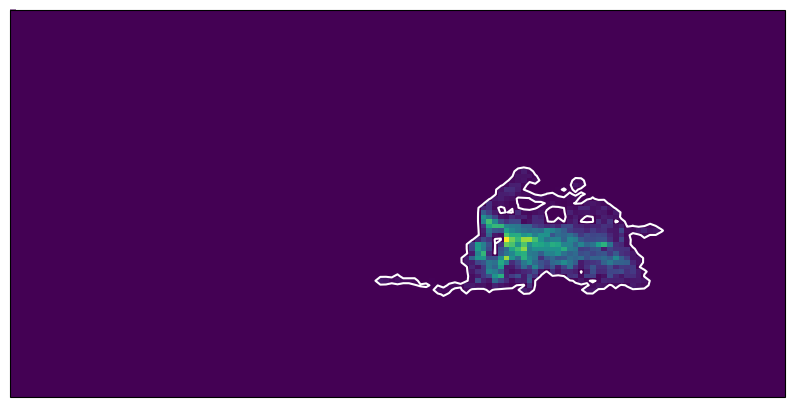

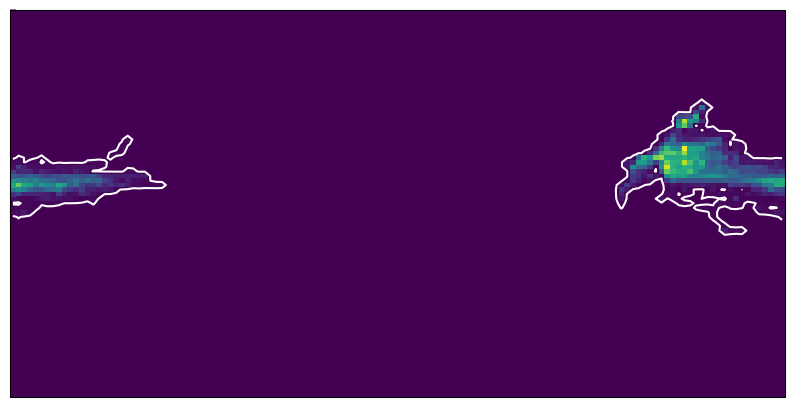

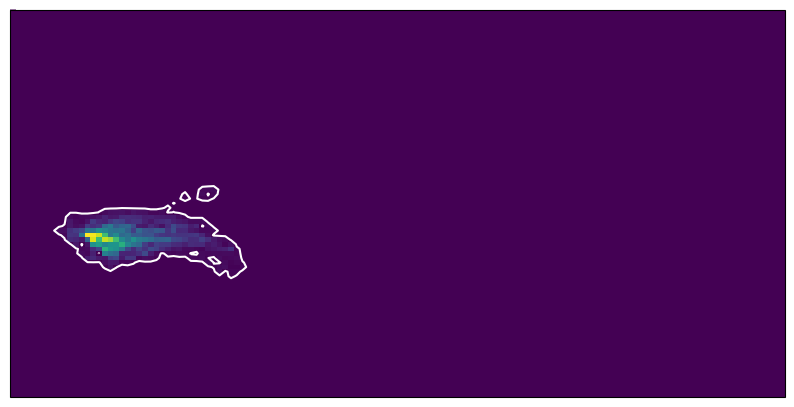

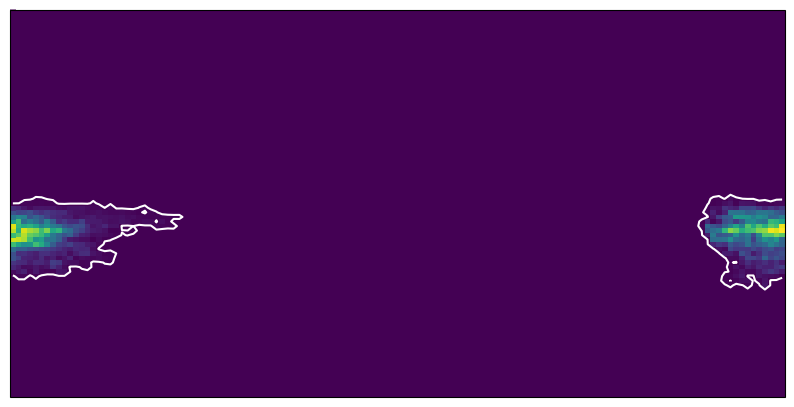

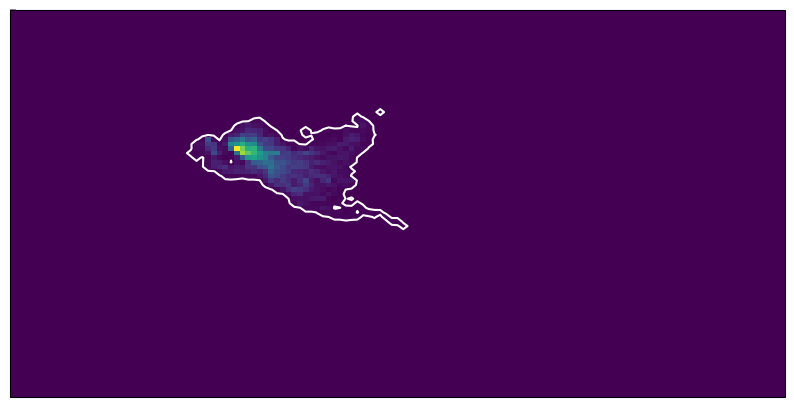

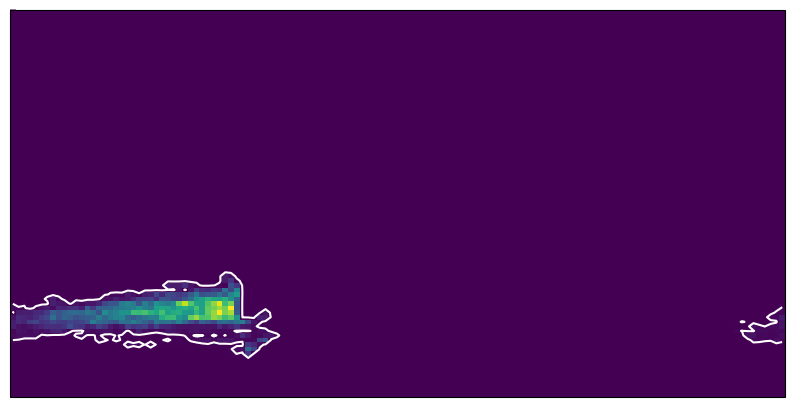

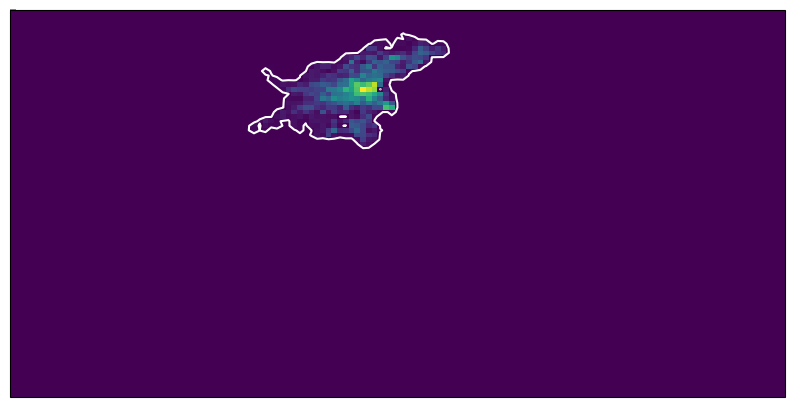

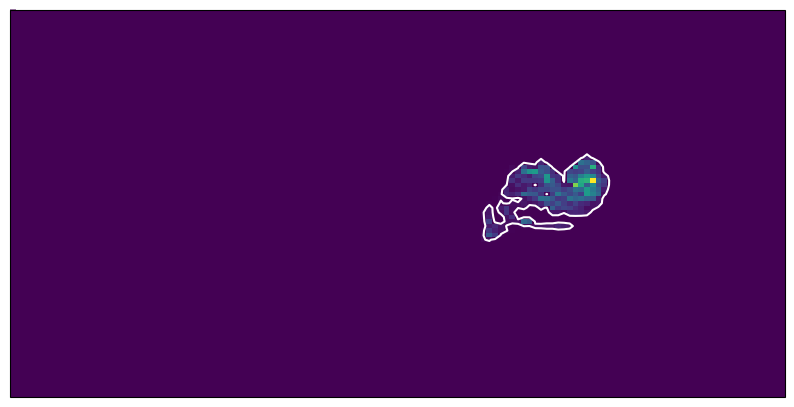

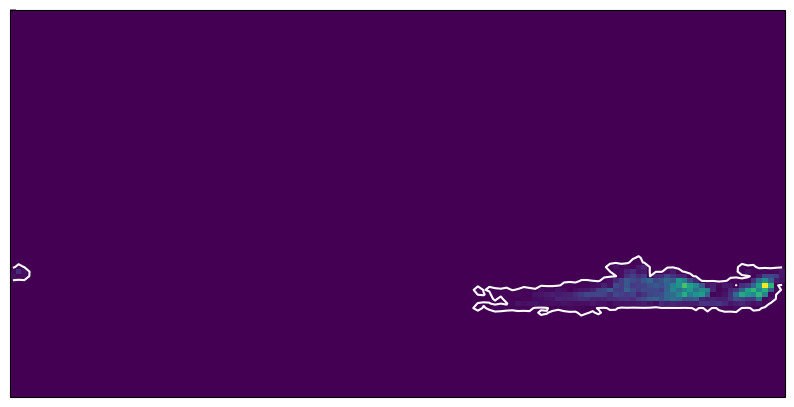

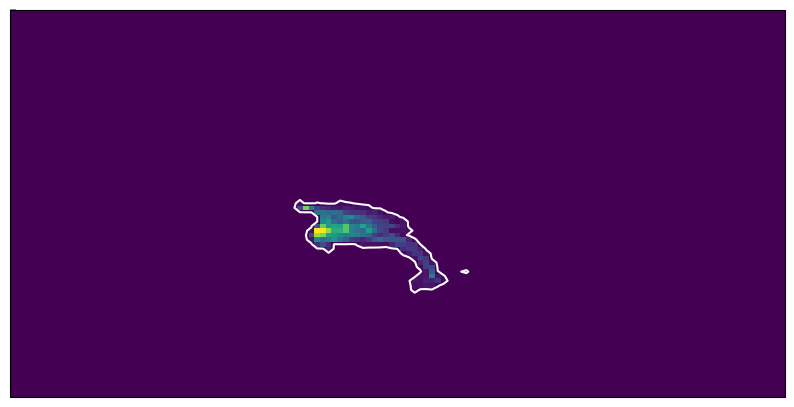

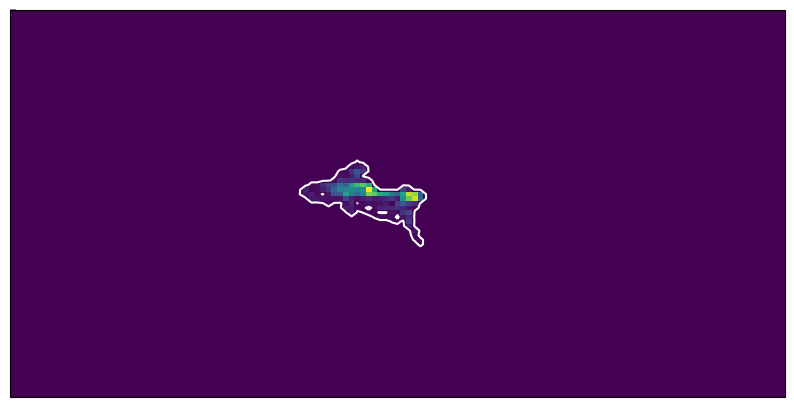

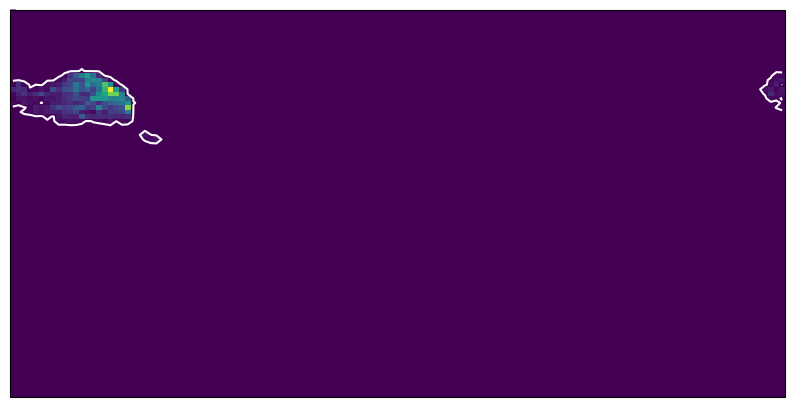

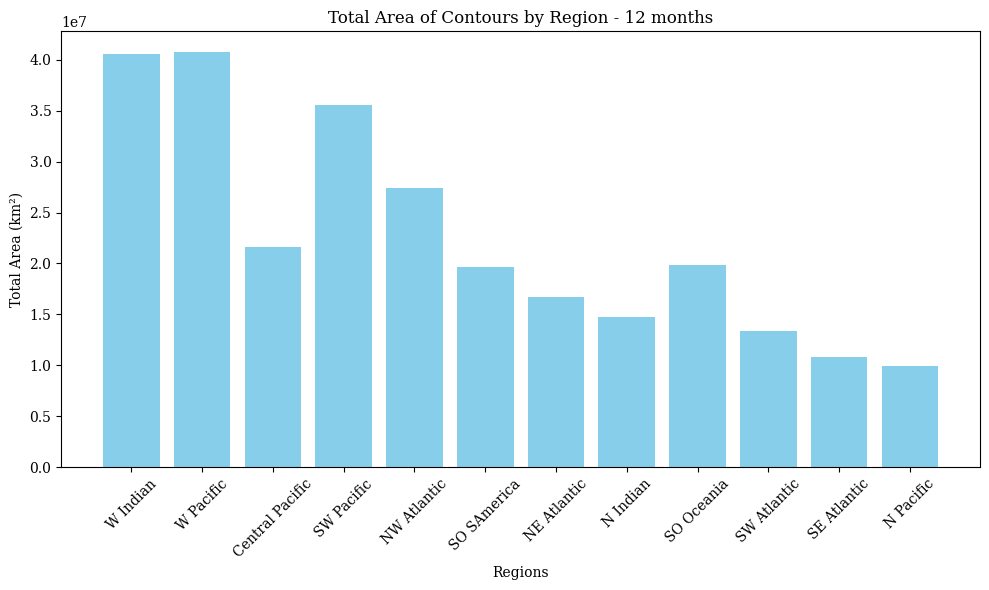

In [147]:
# calculate areas of one year trajectories
area_results = {}
for region, file in dataframes.items():
    total_area = year_area(file)
    area_results[region] = total_area

total_area = sum(area_results.values())
print("Total Area:", total_area)
    
# create plot
plt.figure(figsize=(10, 6))
plt.bar(area_results.keys(), area_results.values(), color='skyblue')
plt.xlabel('Regions')
plt.ylabel('Total Area (km²)')
plt.title('Total Area of Contours by Region - 12 months')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

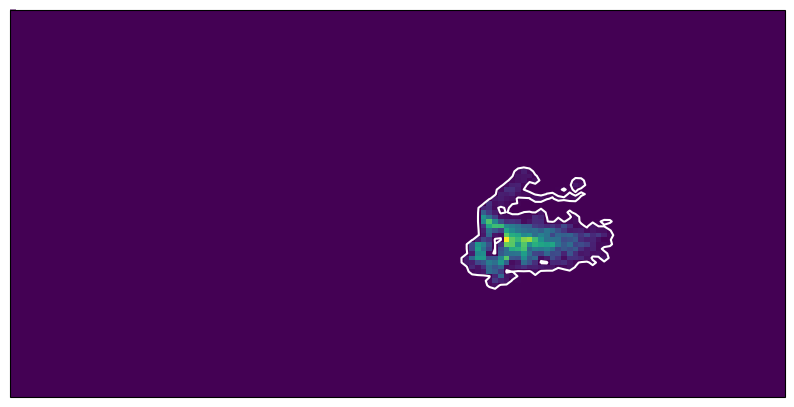

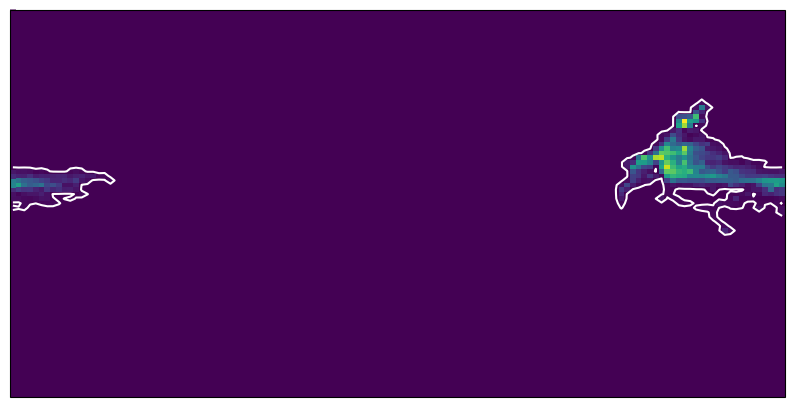

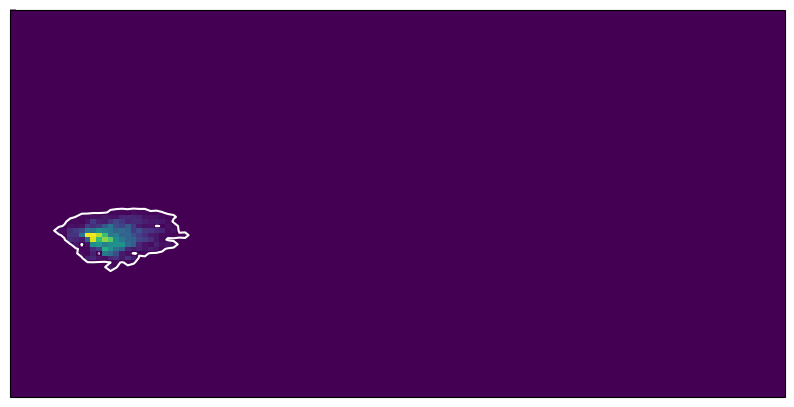

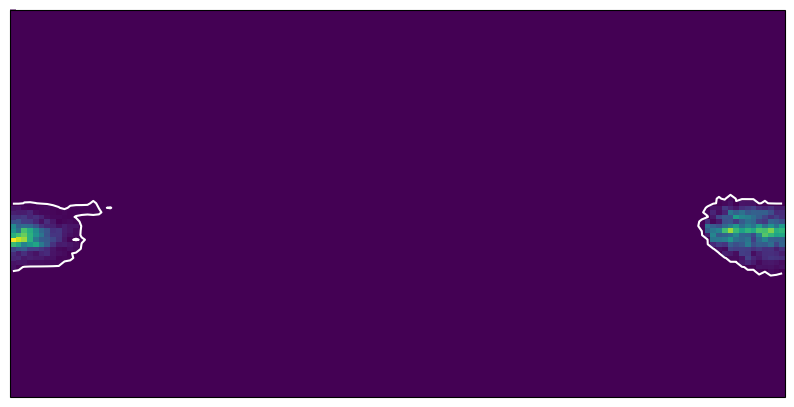

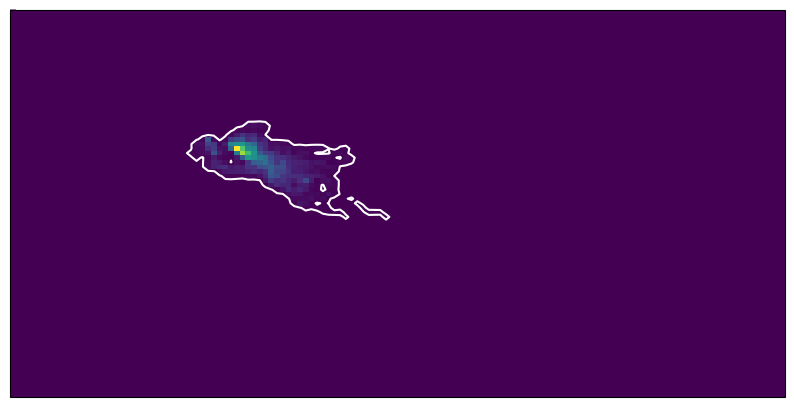

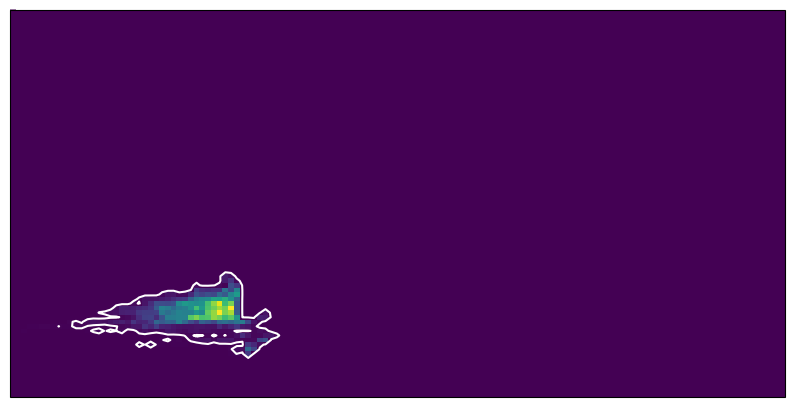

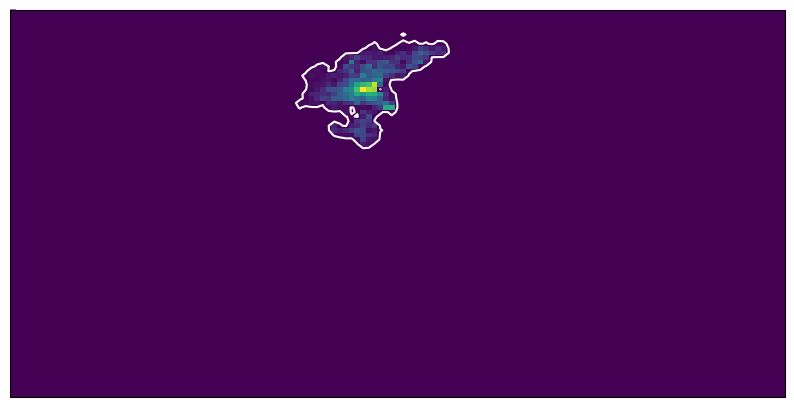

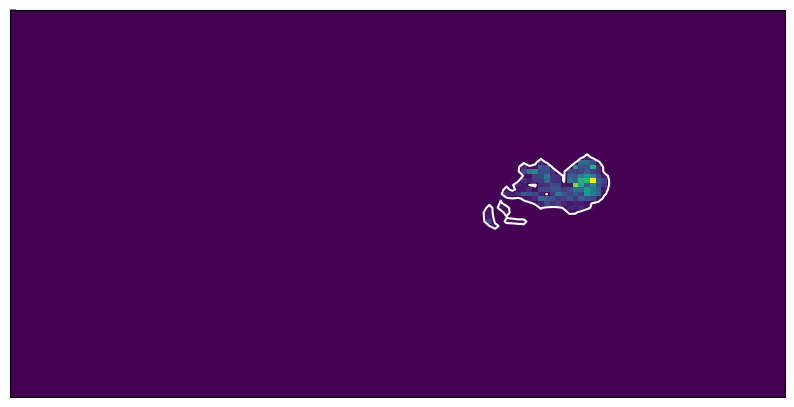

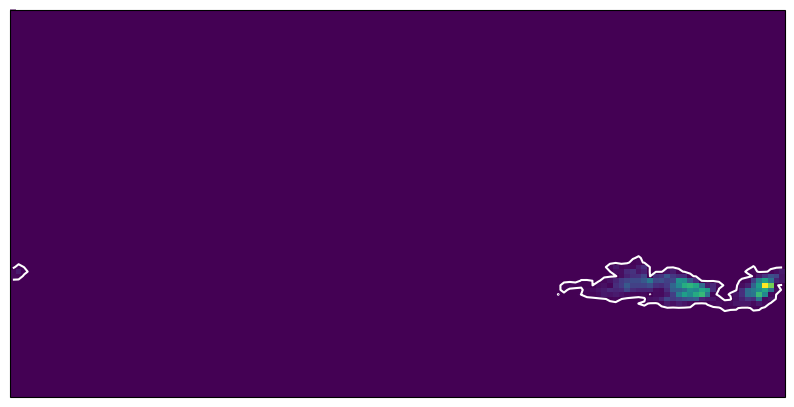

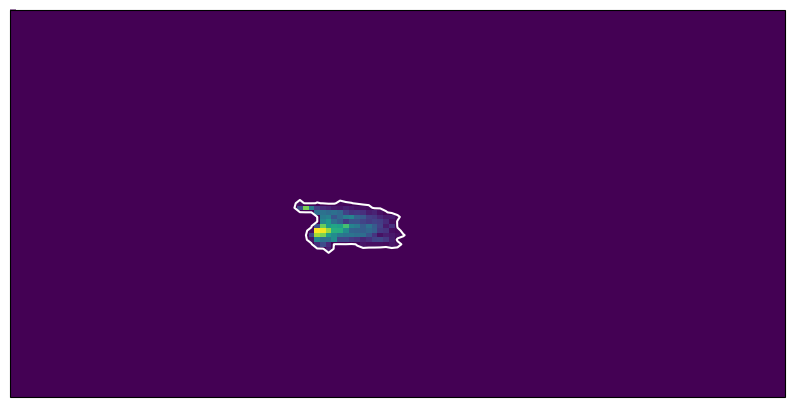

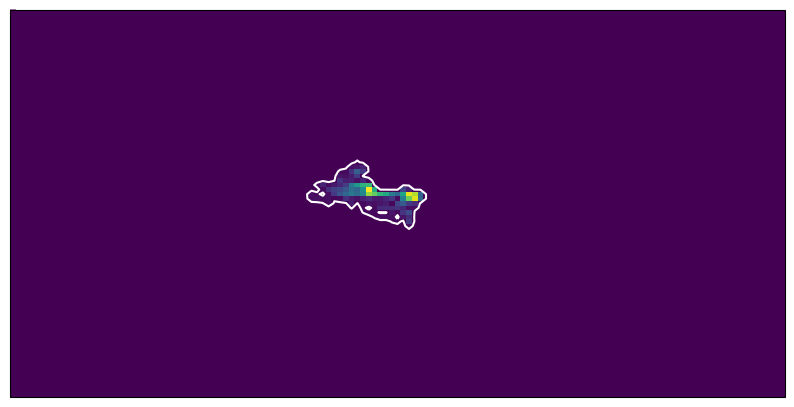

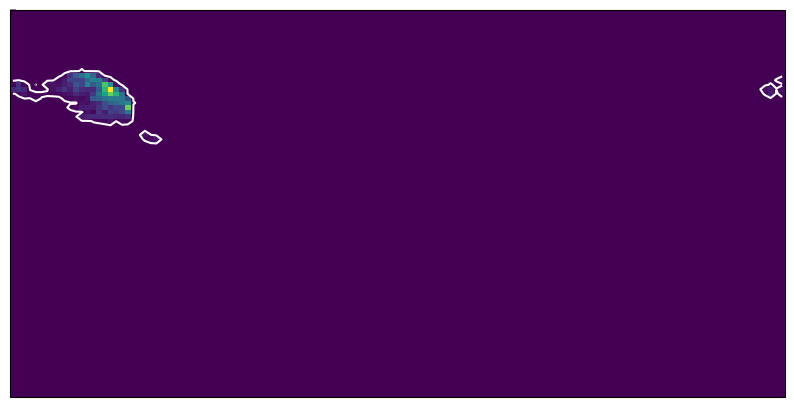

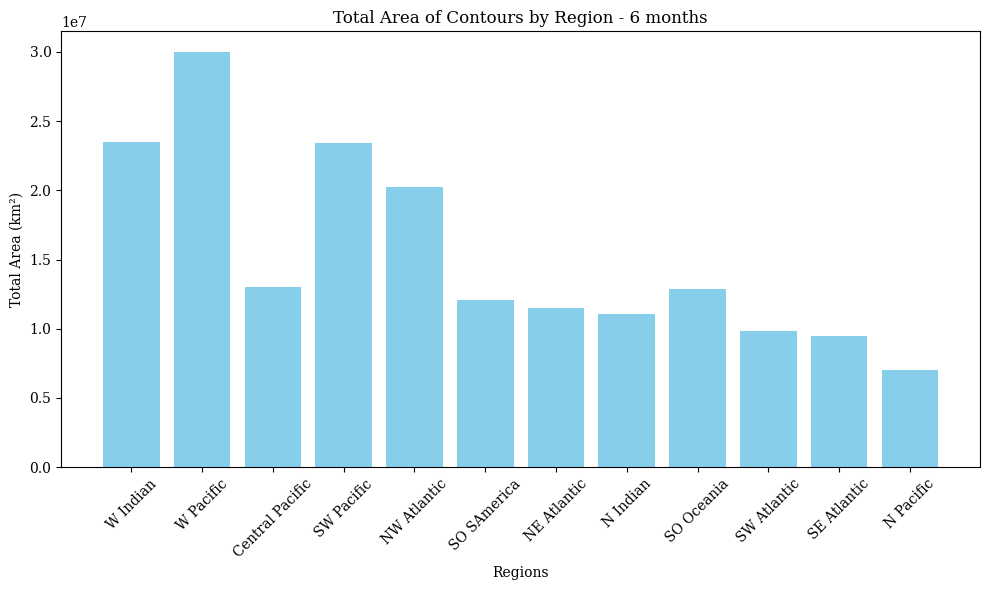

In [148]:
# calculate areas of six month trajectories
area_results = {}
for region, file in dataframes.items():
    total_area = six_area(file)
    area_results[region] = total_area

# create plot
plt.figure(figsize=(10, 6))
plt.bar(area_results.keys(), area_results.values(), color='skyblue')
plt.xlabel('Regions')
plt.ylabel('Total Area (km²)')
plt.title('Total Area of Contours by Region - 6 months')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

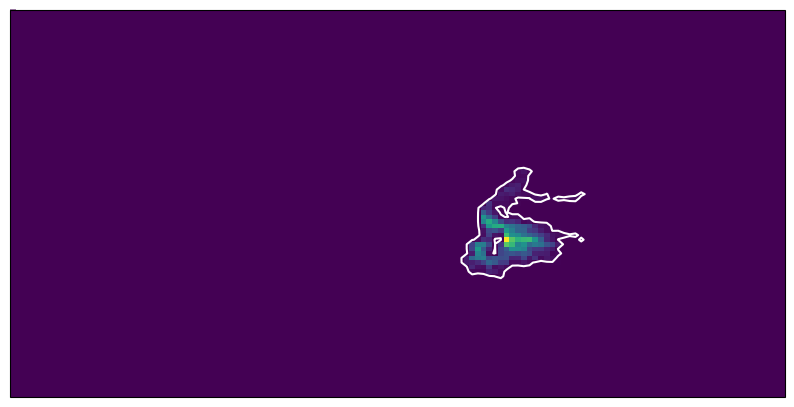

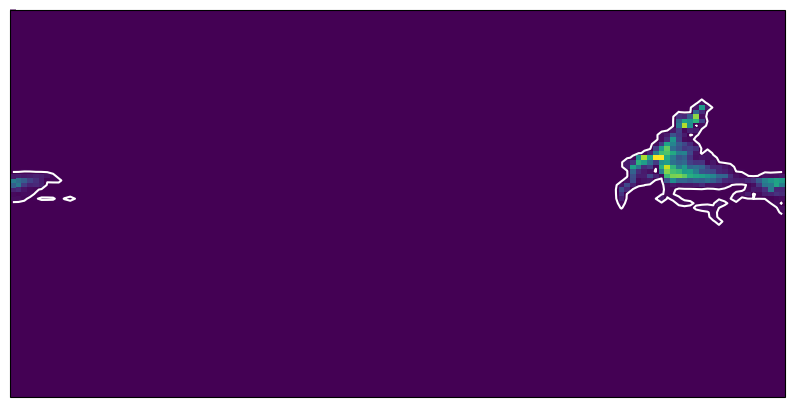

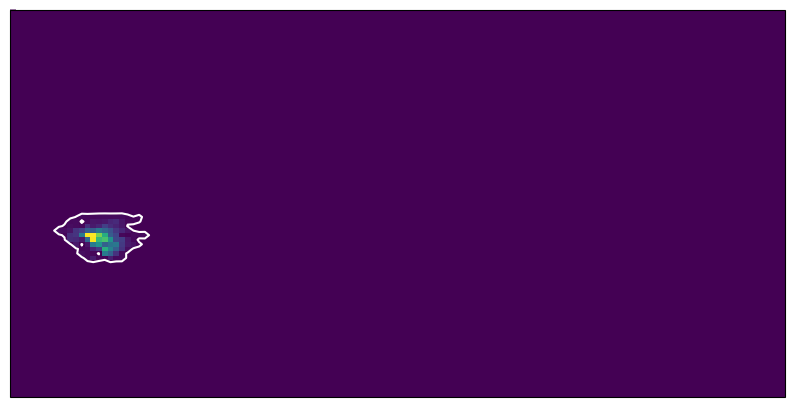

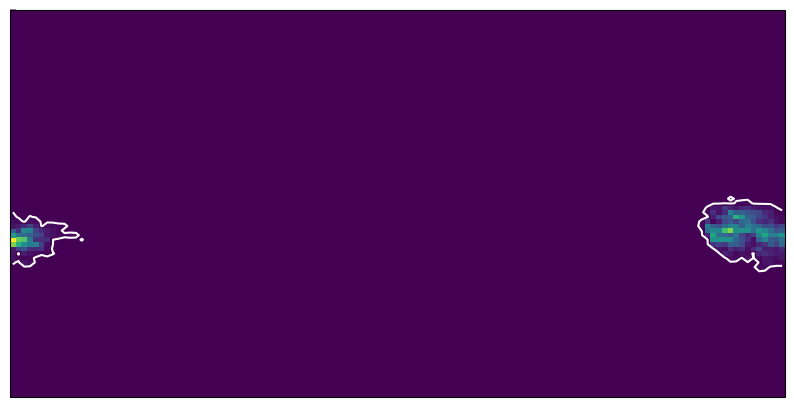

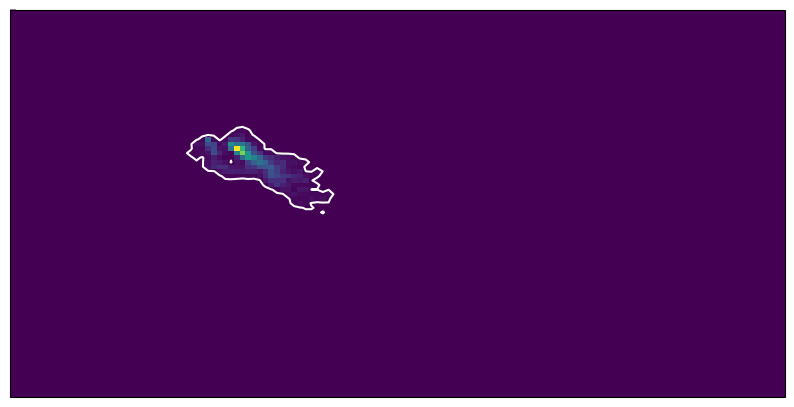

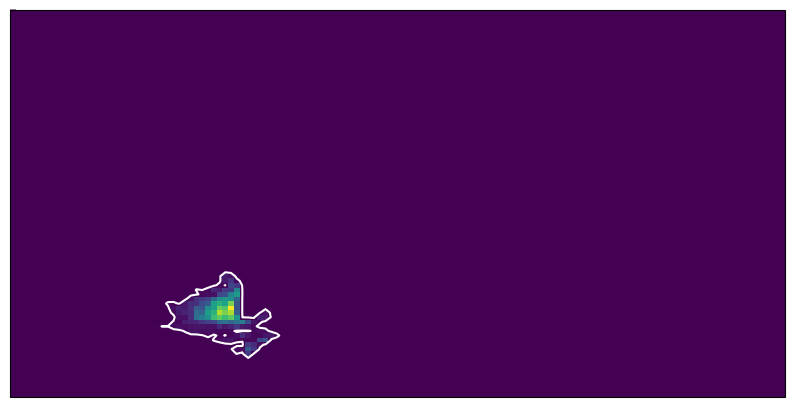

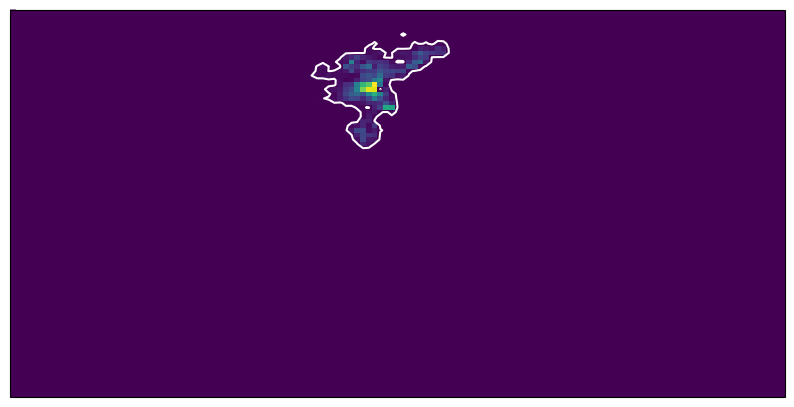

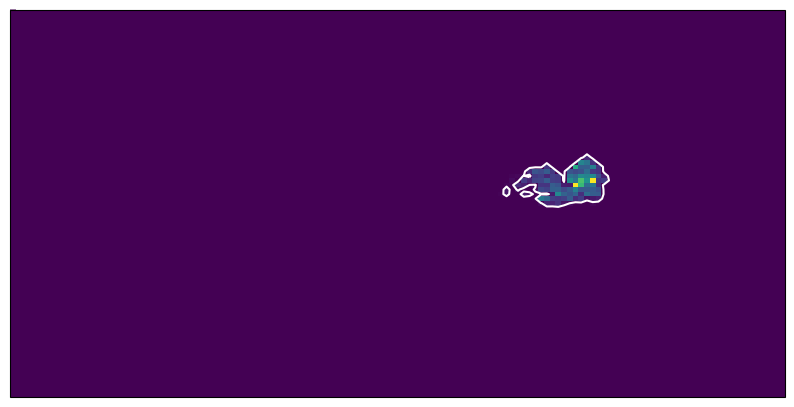

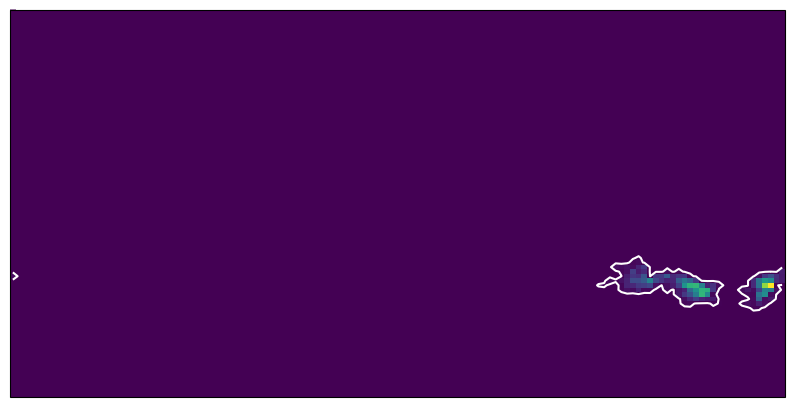

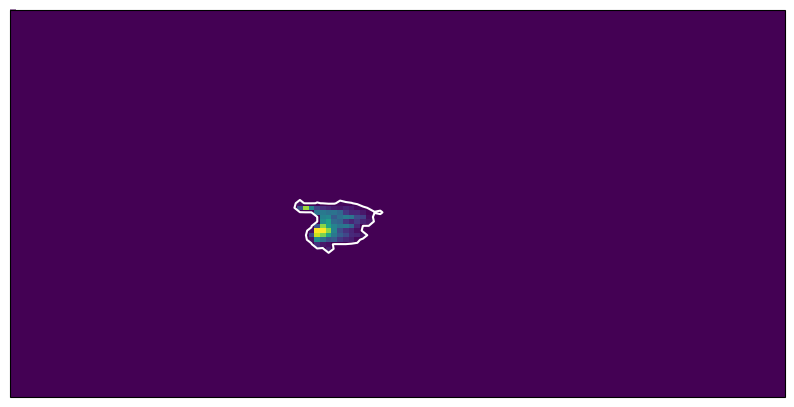

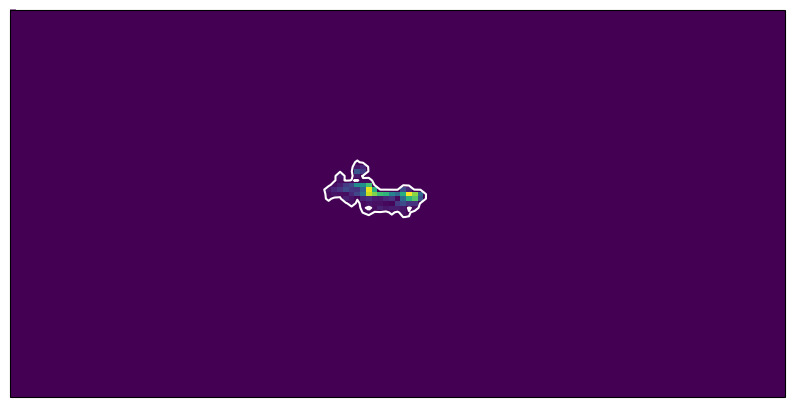

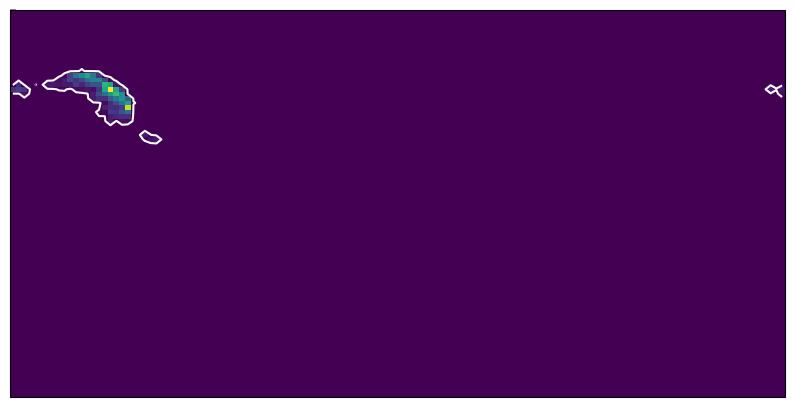

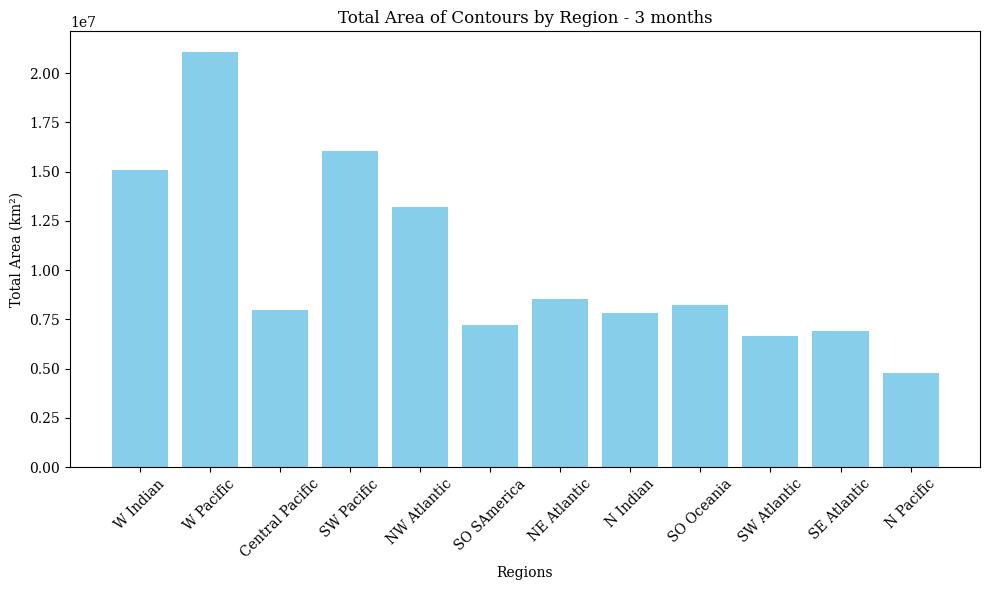

In [149]:
# calculate areas of three month trajectories
area_results = {}
for region, file in dataframes.items():
    total_area = three_area(file)
    area_results[region] = total_area

# create plot
plt.figure(figsize=(10, 6))
plt.bar(area_results.keys(), area_results.values(), color='skyblue')
plt.xlabel('Regions')
plt.ylabel('Total Area (km²)')
plt.title('Total Area of Contours by Region - 3 months')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

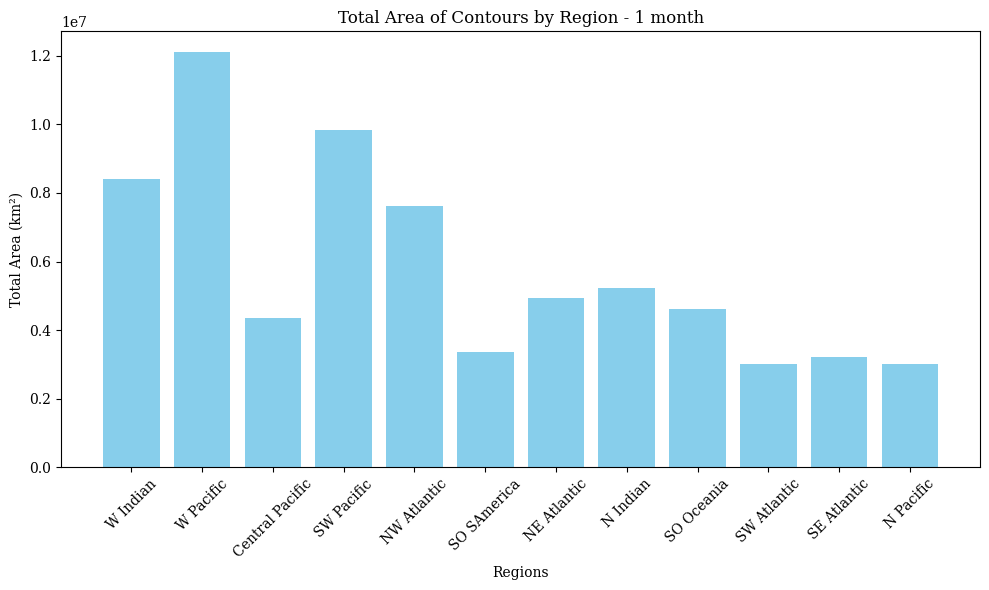

In [150]:
# calculate areas of one month trajectories
area_results = {}
for region, file in dataframes.items():
    total_area = one_area(file)
    area_results[region] = total_area

# create plot
plt.figure(figsize=(10, 6))
plt.bar(area_results.keys(), area_results.values(), color='skyblue')
plt.xlabel('Regions')
plt.ylabel('Total Area (km²)')
plt.title('Total Area of Contours by Region - 1 month')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### initialize final bar plot

/tmp/ipykernel_55492/3430234277.py:10: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(10, 6))


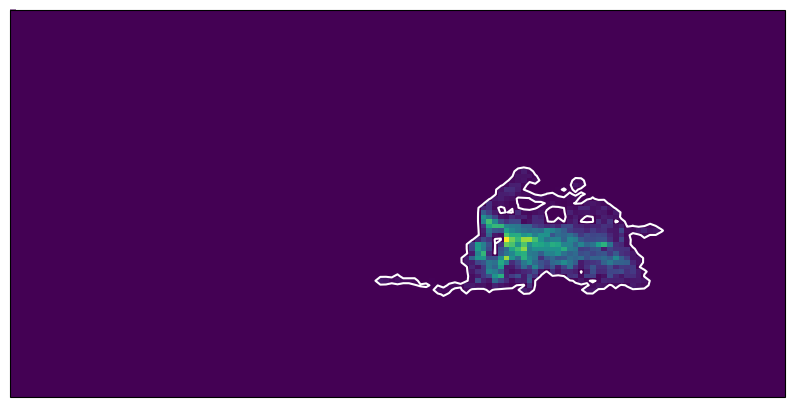

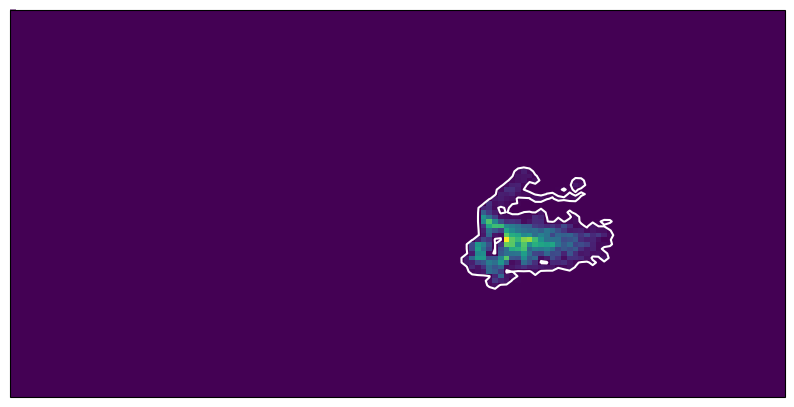

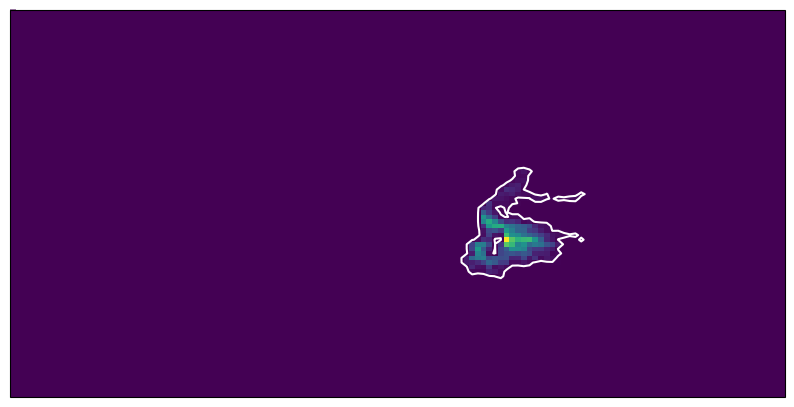

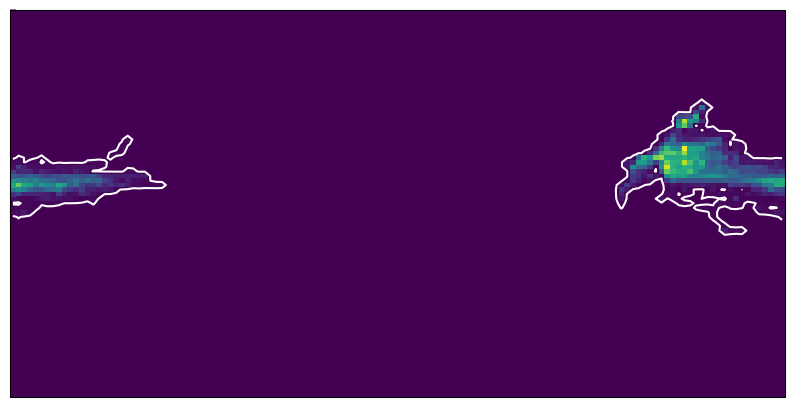

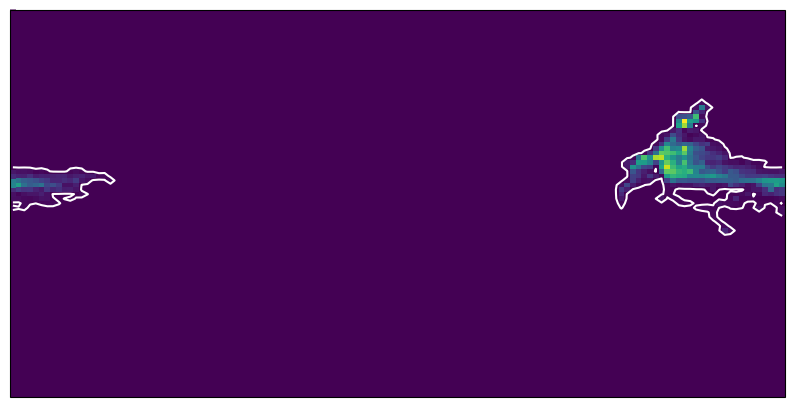

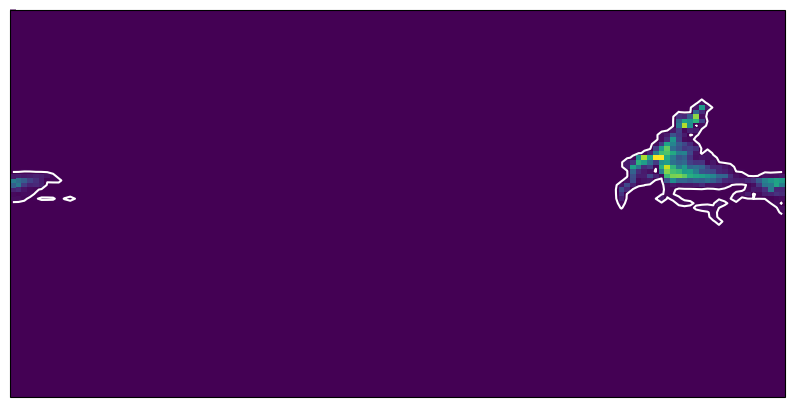

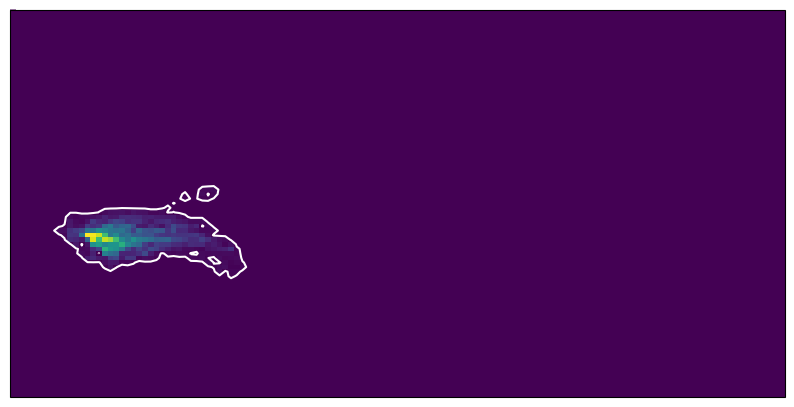

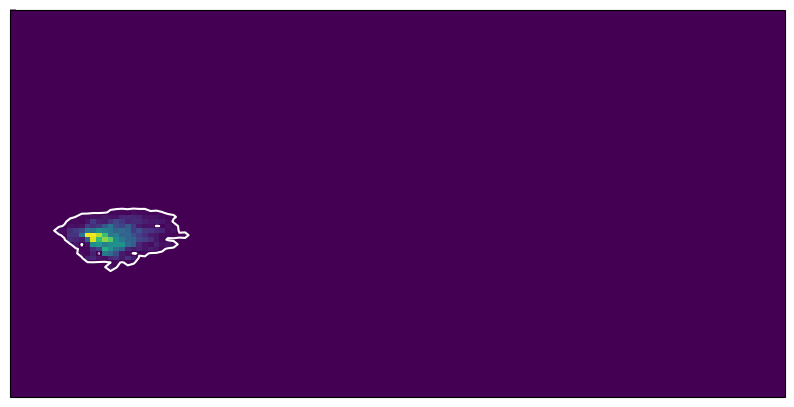

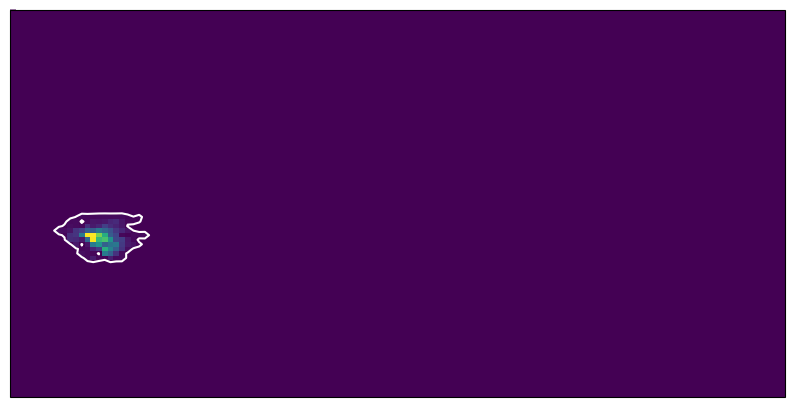

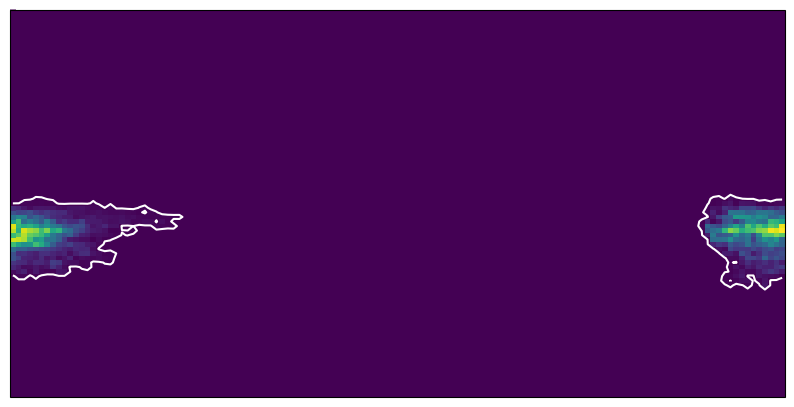

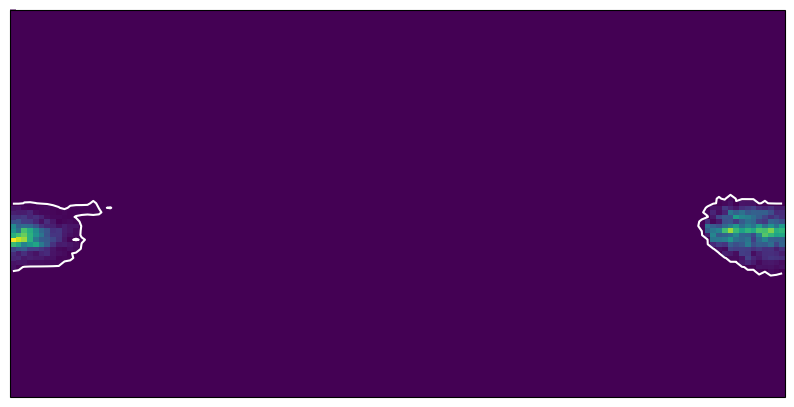

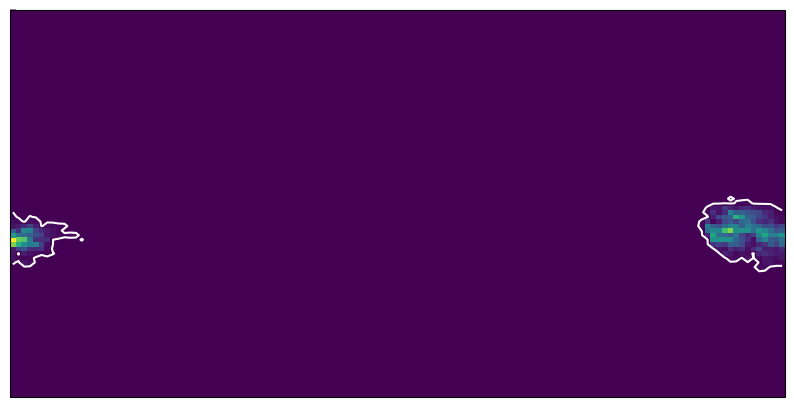

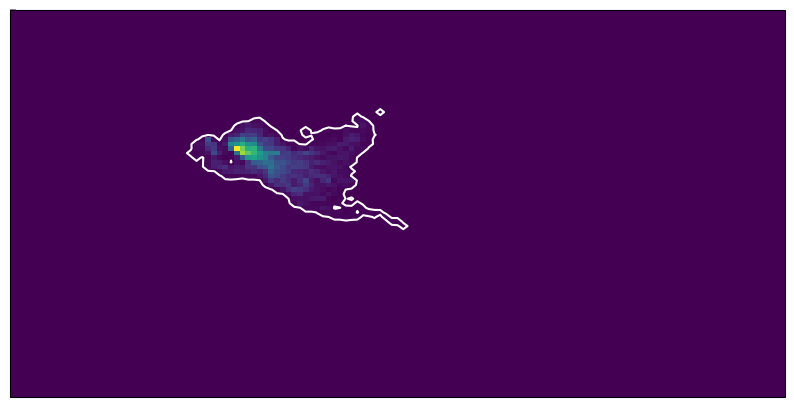

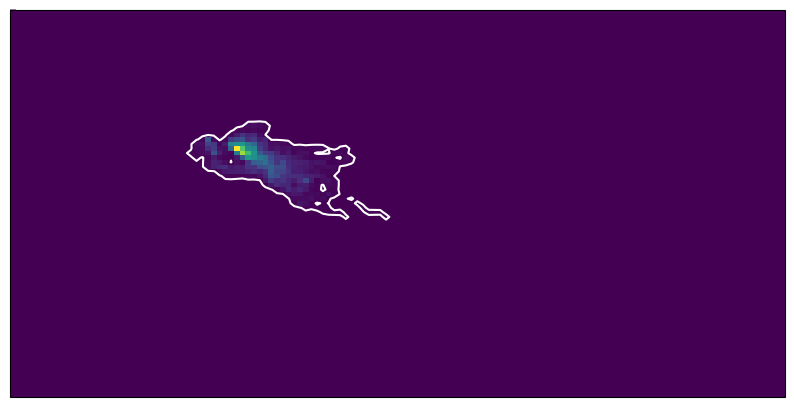

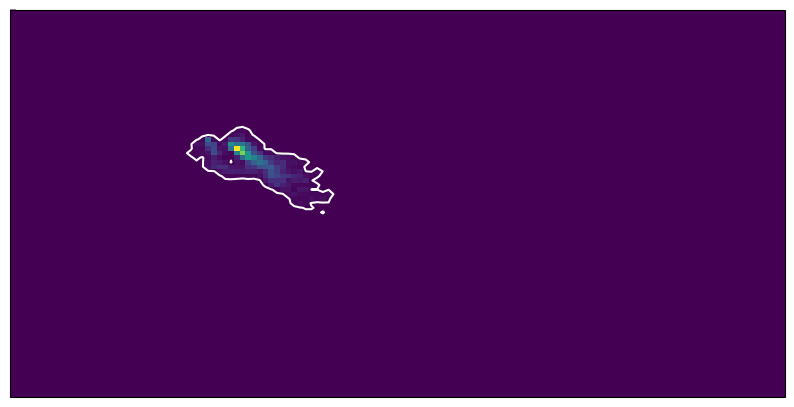

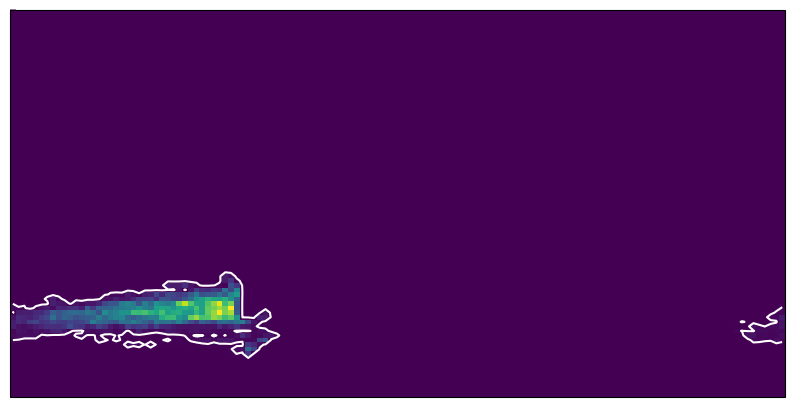

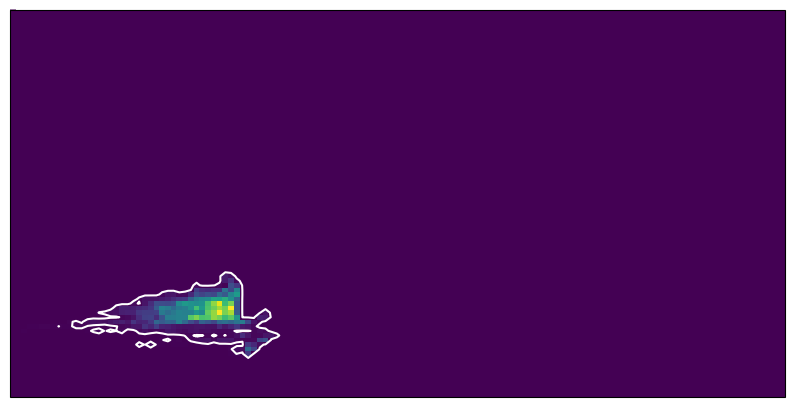

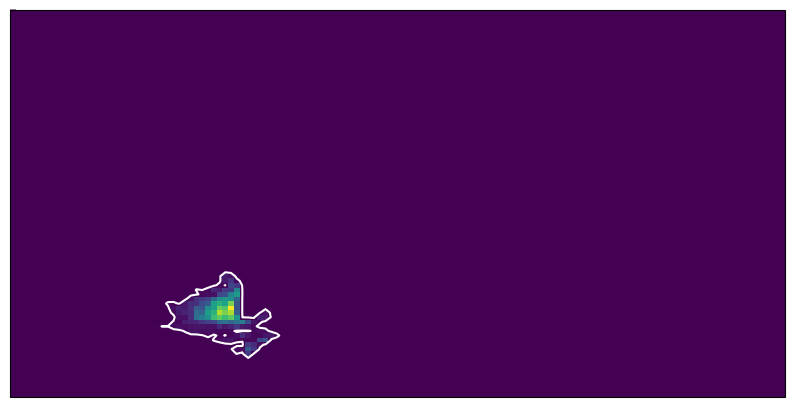

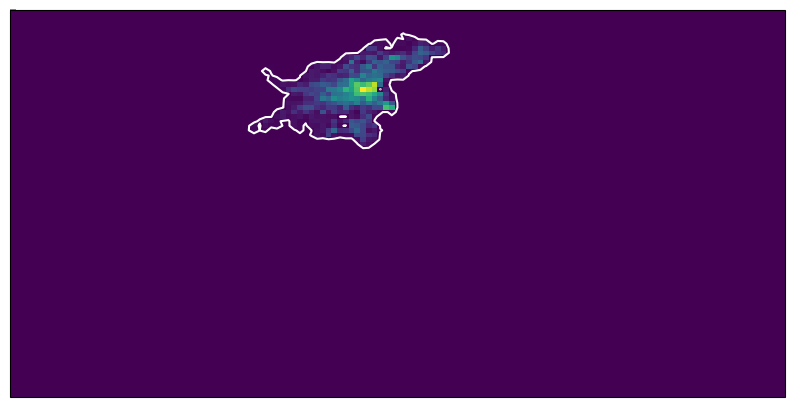

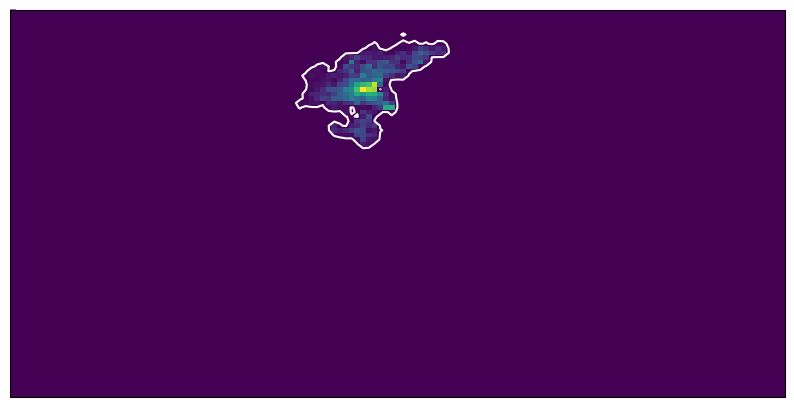

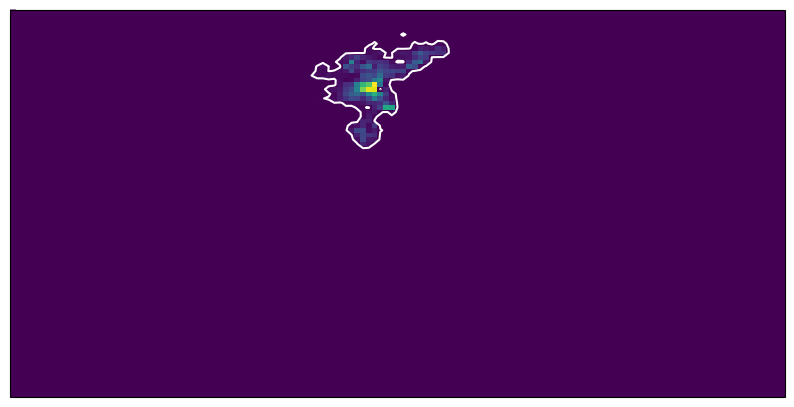

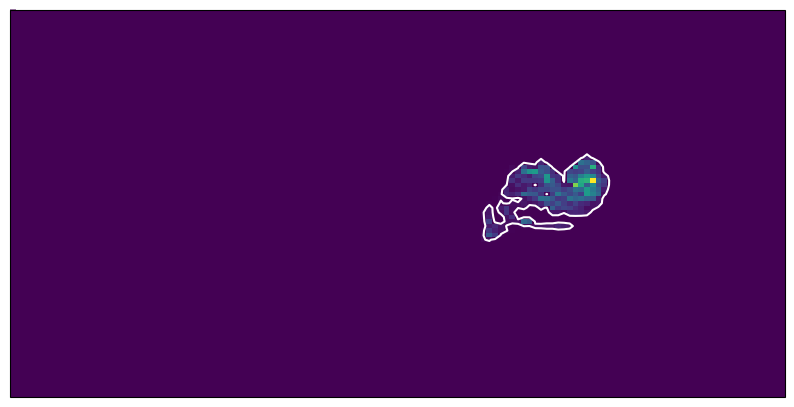

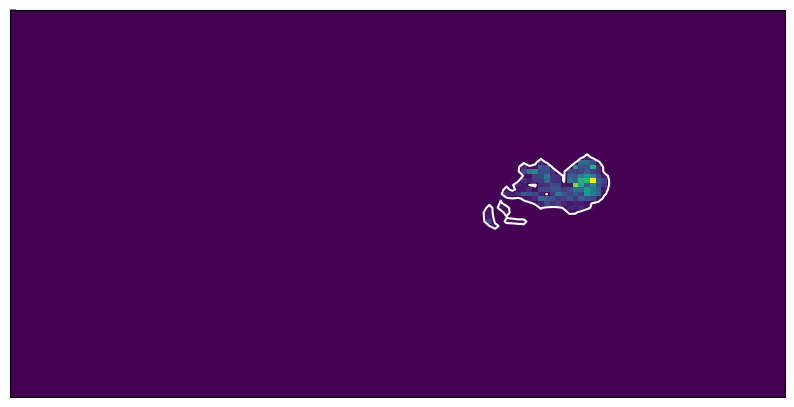

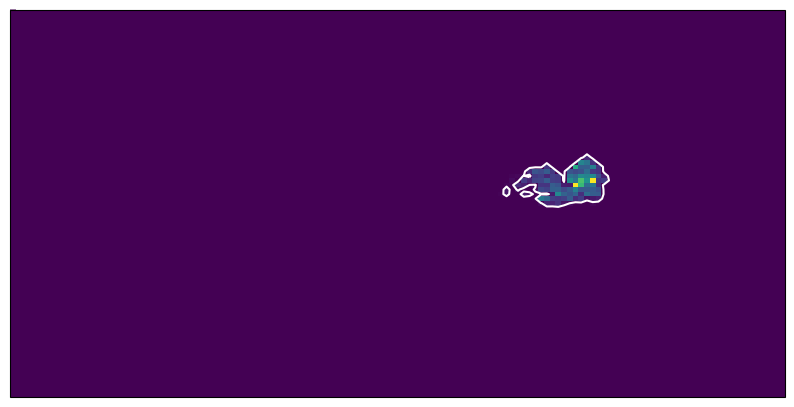

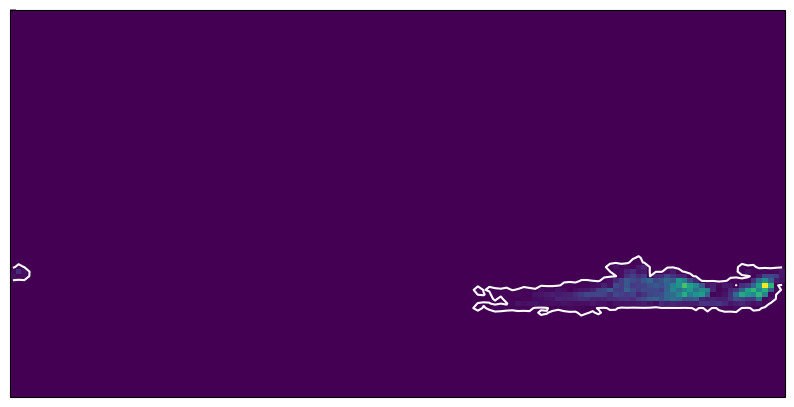

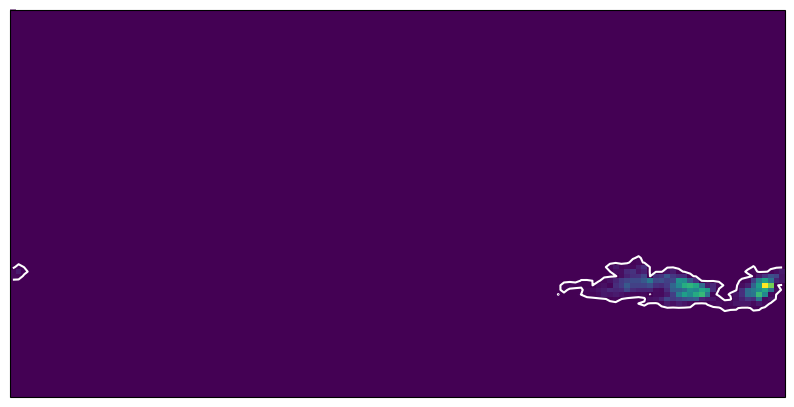

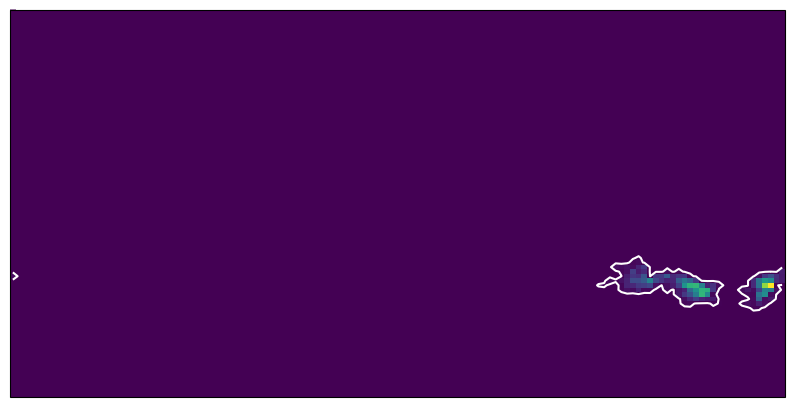

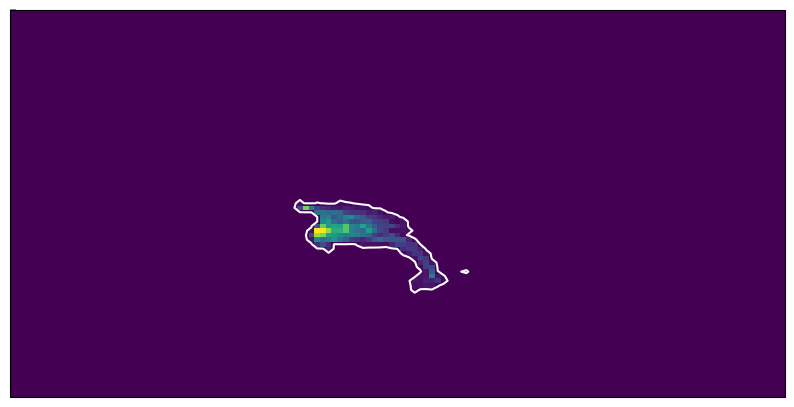

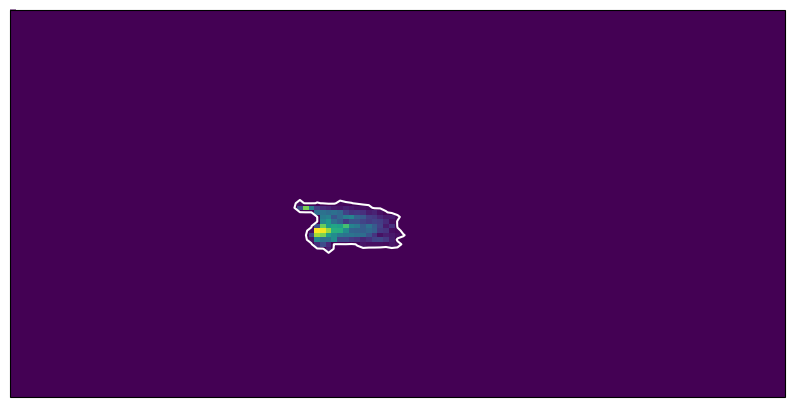

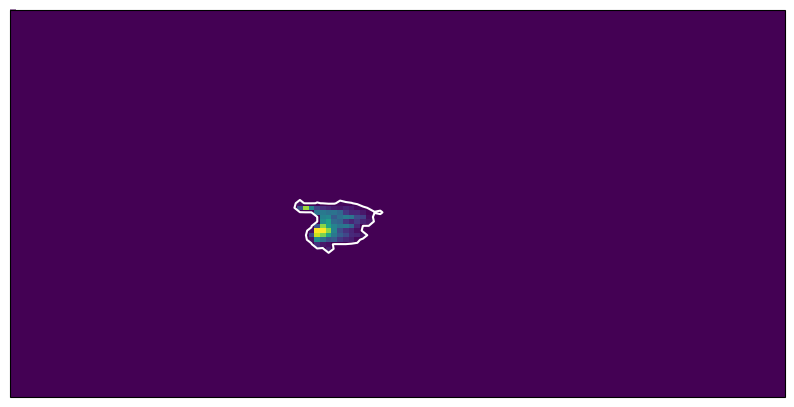

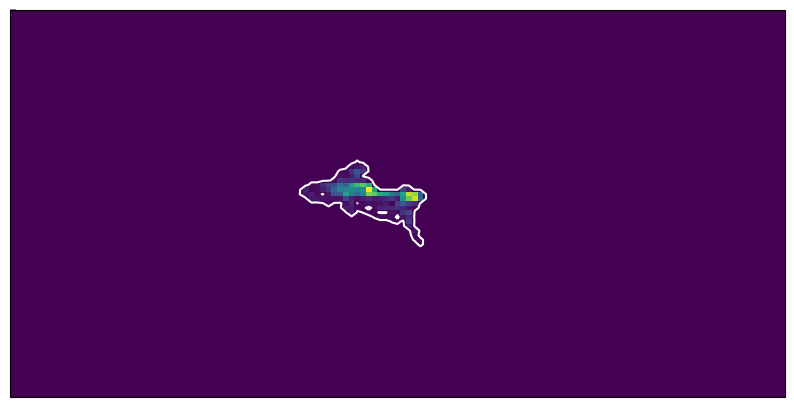

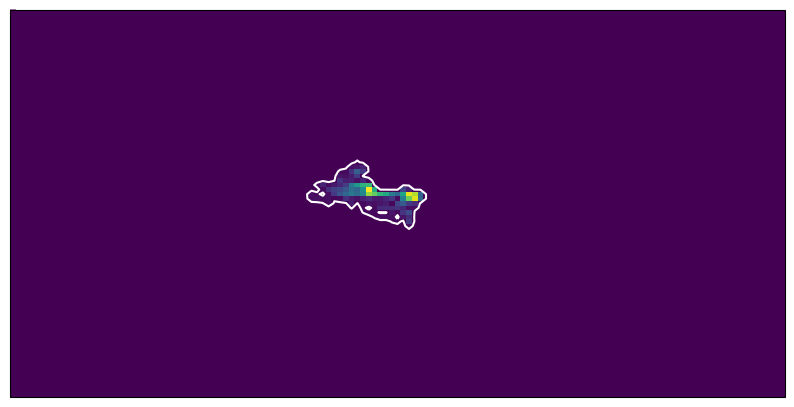

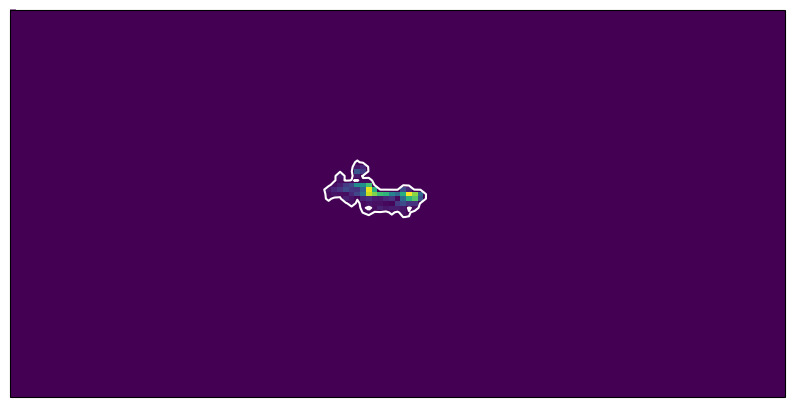

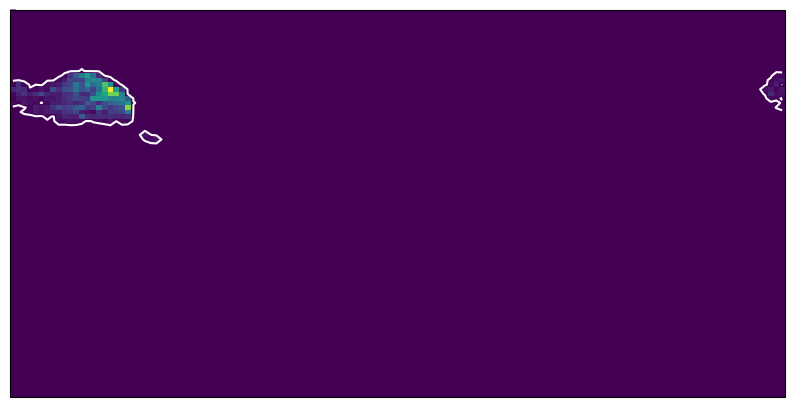

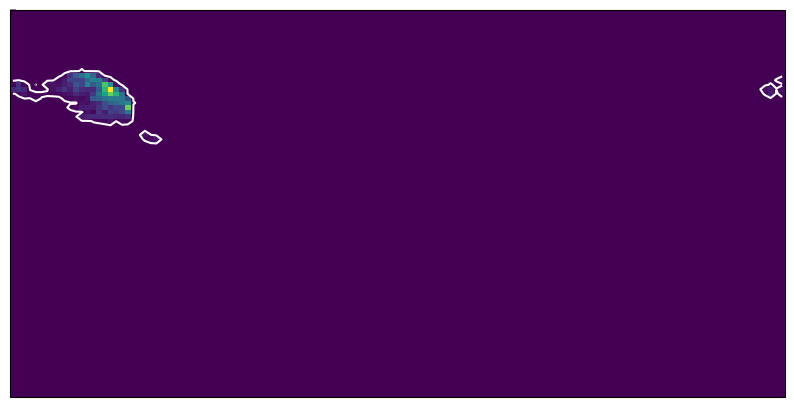

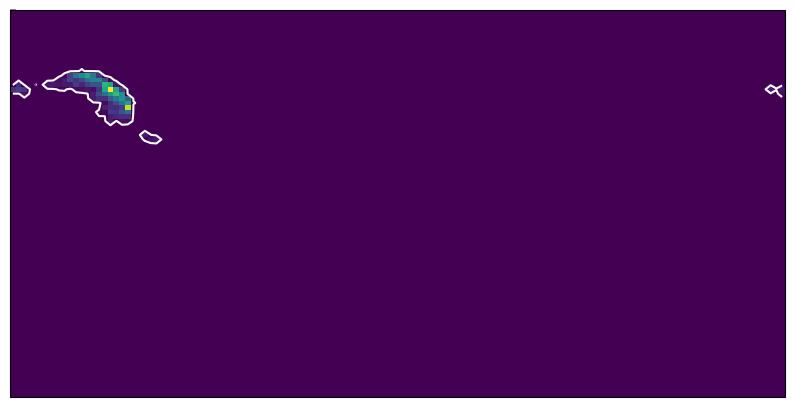

In [151]:
# Initialize empty dictionaries to store the areas for different periods
area_12_months = {}
area_6_months = {}
area_3_months = {}
area_1_month = {}

# Calculate areas for each period and store in dictionaries
for region, file in dataframes.items():
    area_12_months[region] = year_area(file)  # 12 months
    area_6_months[region] = six_area(file)    # 6 months
    area_3_months[region] = three_area(file)  # 3 months
    area_1_month[region] = one_area(file)     # 1 month

# Convert dictionaries to lists of values for plotting
regions = list(area_12_months.keys())  # List of regions
area_12_vals = np.array([area_12_months[region] for region in regions])
area_6_vals = np.array([area_6_months[region] for region in regions])
area_3_vals = np.array([area_3_months[region] for region in regions])
area_1_vals = np.array([area_1_month[region] for region in regions])

area_1_vals
area_3_val = area_3_vals - area_1_vals
area_6_val = area_6_vals - (area_3_val + area_1_vals)
area_12_val = area_12_vals - (area_6_val + area_3_val + area_1_vals)

In [152]:
total_area_12 = np.sum(area_12_vals)
print("Total Area (12 months):", total_area_12)

Total Area (12 months): 270864129.4377996


In [153]:
area_12_vals

array([40551149.66155449, 40764927.09837428, 21635203.83241564,
       35536267.6173043 , 27428404.80055588, 19661165.97378149,
       16743785.82844189, 14695874.91040867, 19825364.65327234,
       13322068.35311732, 10767196.95869232,  9932719.74988092])

Total Area (12 months): 9932719.749880921


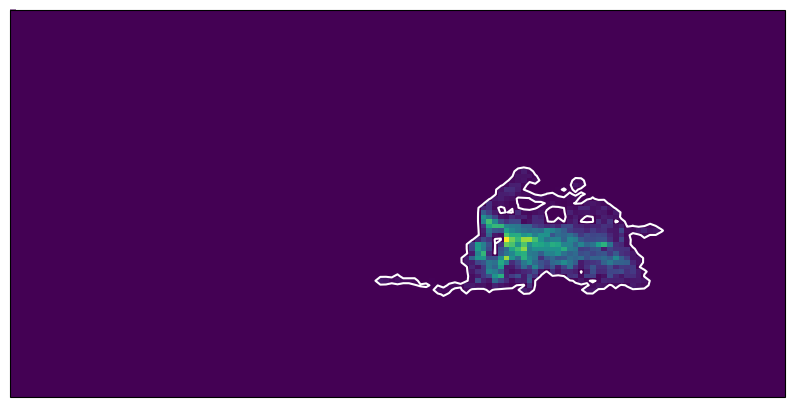

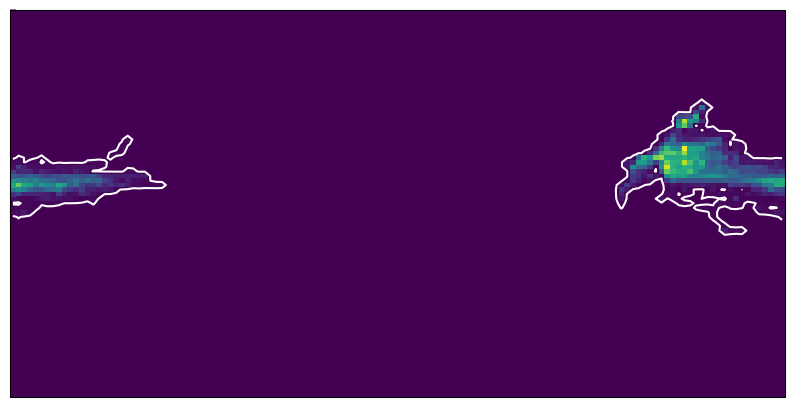

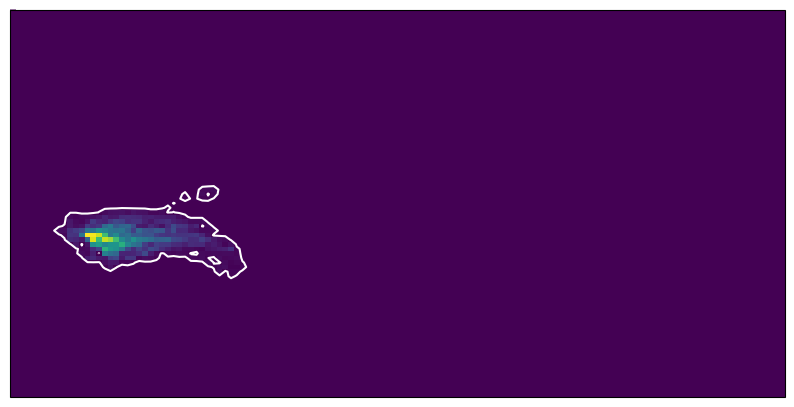

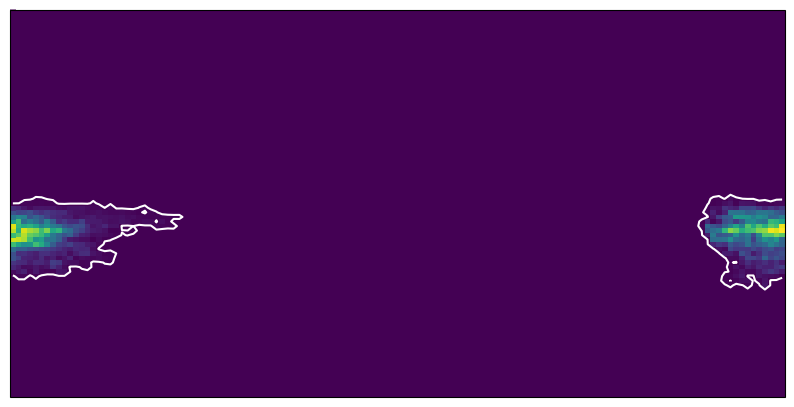

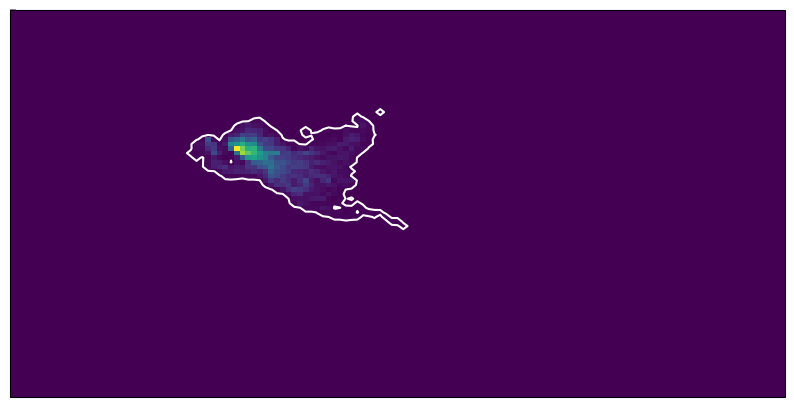

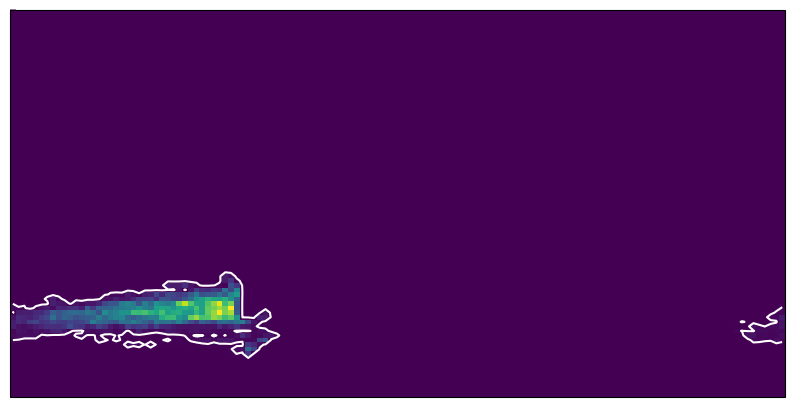

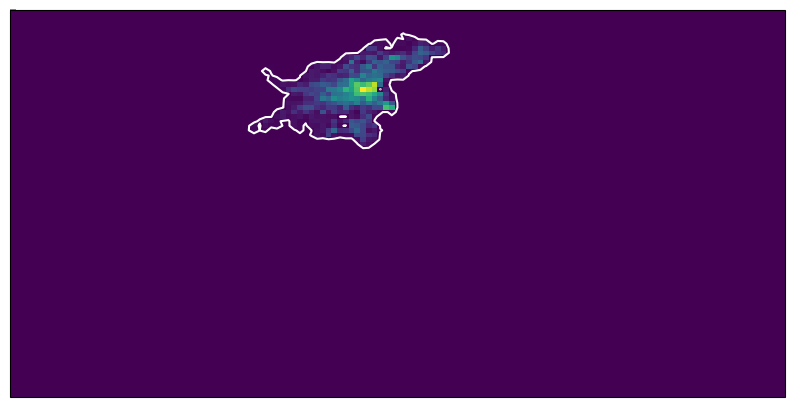

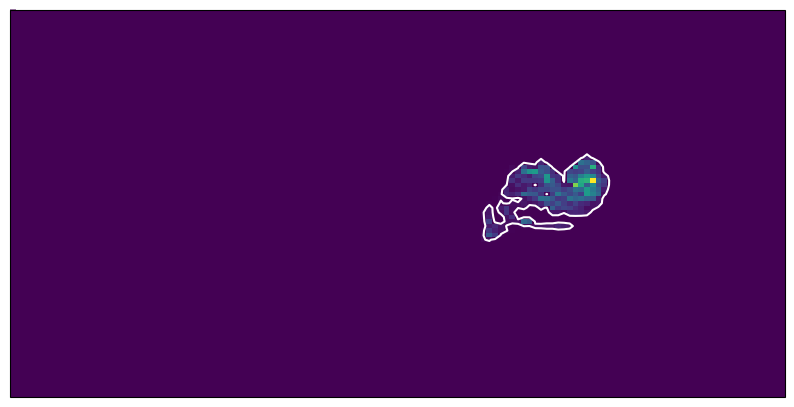

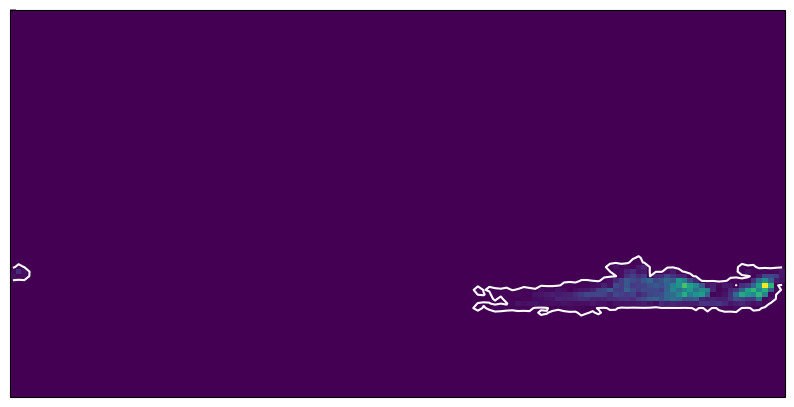

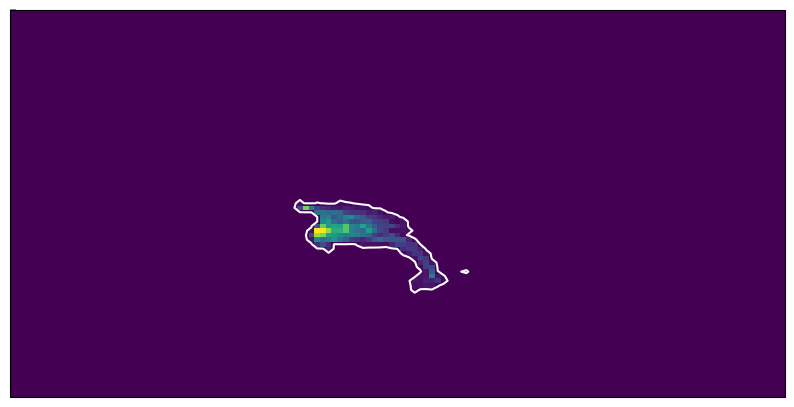

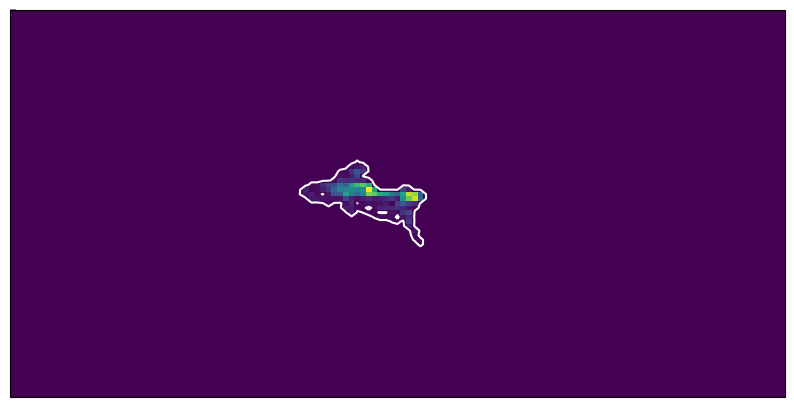

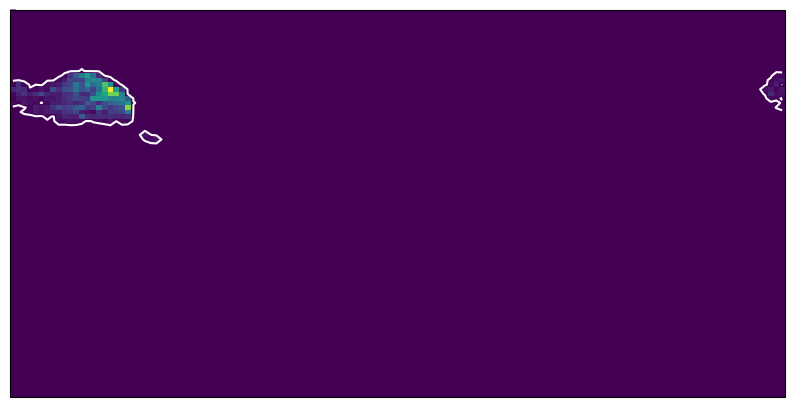

In [154]:
area_results = {}
for region, file in dataframes.items():
    total_area1 = year_area(file)
    area_results[region] = total_area1
total_area_1 = np.sum(total_area1)
print("Total Area (12 months):", total_area_1)

#### final bar plot

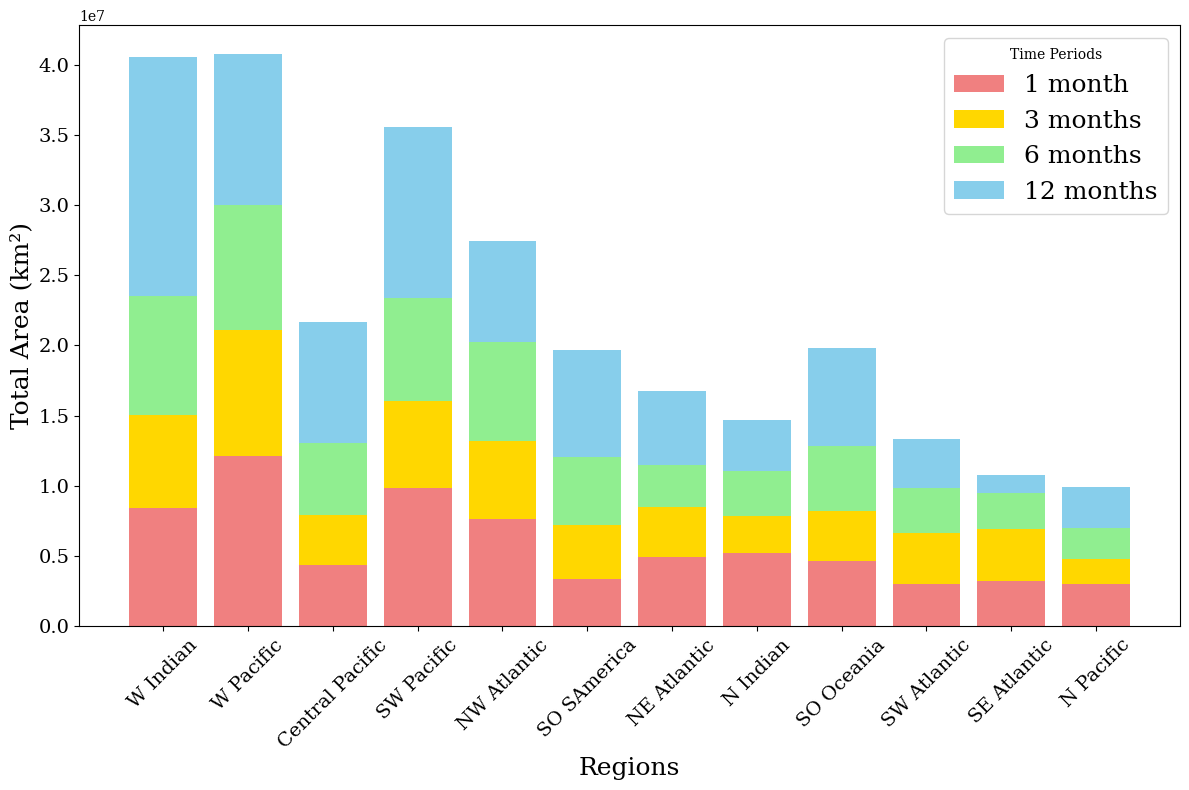

In [155]:
# Create a stacked bar plot
plt.figure(figsize=(12, 8))

# Stack the different time periods
plt.bar(regions, area_1_vals, label='1 month', color='lightcoral')
plt.bar(regions, area_3_val, bottom=area_1_vals, label='3 months', color='gold')
plt.bar(regions, area_6_val, bottom=area_1_vals + area_3_val, label='6 months', color='lightgreen')
plt.bar(regions, area_12_val, bottom=area_1_vals + area_3_val + area_6_val, label='12 months', color='skyblue')

# Add labels and title
plt.xlabel('Regions', fontsize=18)
plt.ylabel('Total Area (km²)', fontsize=18)
plt.xticks(rotation=45, fontsize=14)
plt.yticks(fontsize=14)
plt.legend(title='Time Periods', fontsize=18)
plt.tight_layout()

# Show the plot
#plt.savefig("Total_Watershed.png")
plt.show()

In [156]:
os.chdir('/home/openonic/global-drifter-program/new')

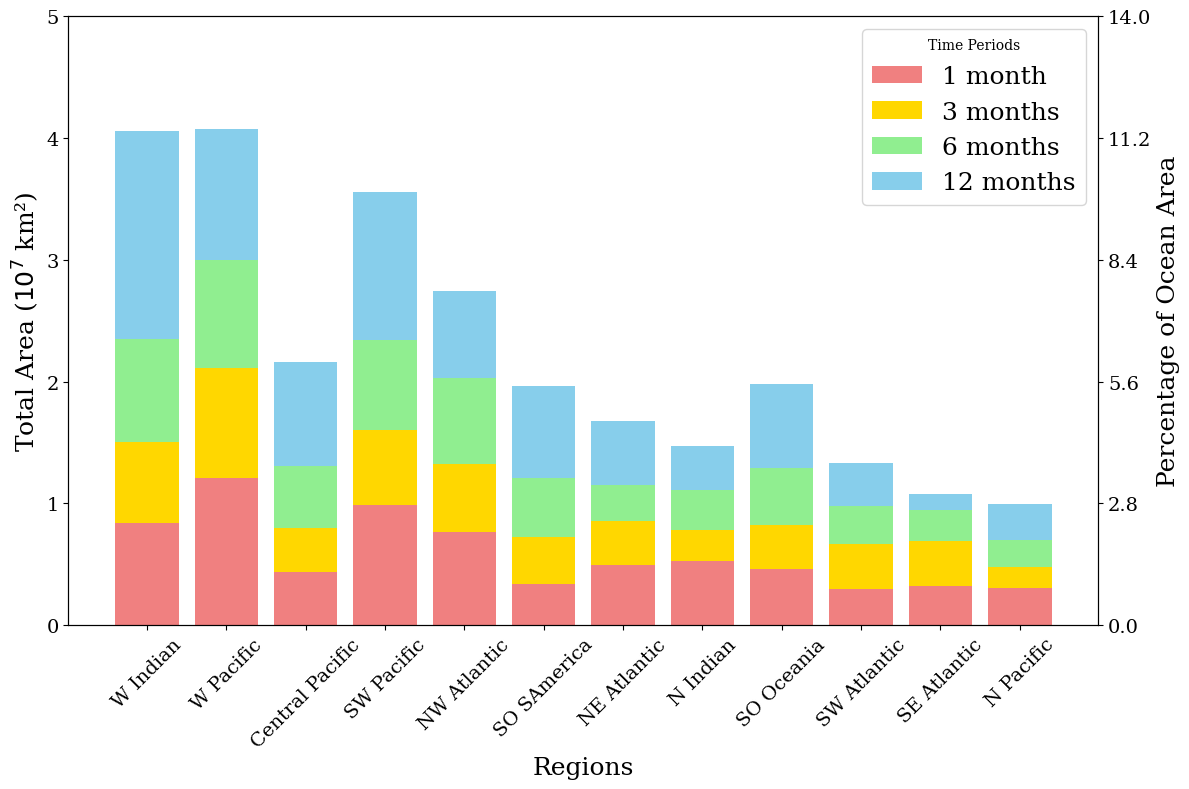

In [157]:
plt.rcParams['font.family'] = 'DejaVu Serif'
# Constants
total_ocean_area_km2 = 361_000_000  # Total ocean area in square kilometers
max_percentage = 14  # Maximum for the secondary y-axis in percentage

# Set the maximum for the primary y-axis (50 million km²)
primary_y_max = 5e7  # 5 * 10^7 km²

# Create the plot
fig, ax1 = plt.subplots(figsize=(12, 8))

# Stack the bars for different time periods
ax1.bar(regions, area_1_vals, label='1 month', color='lightcoral')
ax1.bar(regions, area_3_val, bottom=area_1_vals, label='3 months', color='gold')
ax1.bar(regions, area_6_val, bottom=area_1_vals + area_3_val, label='6 months', color='lightgreen')
ax1.bar(regions, area_12_val, bottom=area_1_vals + area_3_val + area_6_val, label='12 months', color='skyblue')

# Set primary y-axis labels, limit, and ticks
ax1.set_xlabel('Regions', fontsize=18)
ax1.set_ylabel('Total Area ($10^7$ km²)', fontsize=18)
ax1.tick_params(axis='y', labelsize=14)
ax1.tick_params(axis='x', rotation=45, labelsize=14)
ax1.set_ylim(0, primary_y_max)  # Set y-axis limit to 50 million km²
ax1.set_yticks([i * 1e7 for i in range(6)])  # Set ticks at 0, 10, 20, 30, 40, 50 million km²
ax1.set_yticklabels([f"{int(i/1e7)}" for i in ax1.get_yticks()])  # Label ticks as 0, 1, 2, 3, 4, 5 in units of 10 million km²
ax1.legend(title='Time Periods', fontsize=18)

# Add secondary y-axis for the 12-month area as a percentage
ax2 = ax1.twinx()
ax2.set_ylim(0, max_percentage)  # Set secondary y-axis limit to 14%
ax2.set_ylabel('Percentage of Ocean Area', fontsize=18, color='black')
ax2.tick_params(axis='y', labelsize=14, colors='black')
num_ticks_primary_y = len(ax1.get_yticks())
ax2.set_yticks([i * (max_percentage / (num_ticks_primary_y - 1)) for i in range(num_ticks_primary_y)])


# Display the plot
plt.tight_layout()
plt.savefig("figs/Total_Watershed.png")
plt.show()

In [158]:
# Calculate the total area for each region
total_area_per_region = area_12_vals

# Calculate the total percentage of ocean area covered by the four time periods
total_area_covered = sum(total_area_per_region)
total_percentage = (total_area_covered / total_ocean_area_km2) * 100

# Print the total percentage
print(f"Total percentage of ocean area covered: {total_percentage:.2f}%")


Total percentage of ocean area covered: 75.03%


In [159]:
area_12_vals

array([40551149.66155449, 40764927.09837428, 21635203.83241564,
       35536267.6173043 , 27428404.80055588, 19661165.97378149,
       16743785.82844189, 14695874.91040867, 19825364.65327234,
       13322068.35311732, 10767196.95869232,  9932719.74988092])

### area verification

In [112]:
os.chdir('/home/openonic/global-drifter-program/new/full_watersheds')

In [113]:
def compare_areas_to_ocean(ocean_area, area_12_vals, regions):
    """
    Compare the areas for different time periods to the total ocean area and output results, including the sum of percentages.
    
    Parameters:
    - ocean_area (float): Total ocean area in square kilometers.
    - area_12_vals (numpy.array): Array of areas for 12 months (sq km).
    - area_6_vals (numpy.array): Array of areas for 6 months (sq km).
    - area_3_vals (numpy.array): Array of areas for 3 months (sq km).
    - area_1_vals (numpy.array): Array of areas for 1 month (sq km).
    - regions (list): List of region names corresponding to the areas.
    """
    time_periods = {
        "12 Months": area_12_vals,
        "6 Months": area_6_vals,
        "3 Months": area_3_vals,
        "1 Month": area_1_vals,
    }
    
    total_percentage_covered = {
        "12 Months": 0,
        "6 Months": 0,
        "3 Months": 0,
        "1 Month": 0,
    }
    
    print(f"Total Ocean Area: {ocean_area:.2f} sq km\n")

    for period, area_vals in time_periods.items():
        print(f"--- {period} ---")
        for i, region in enumerate(regions):
            contour_area = area_vals[i]
            outside_area = ocean_area - contour_area
            percentage_covered = (contour_area / ocean_area) * 100
            area_difference = ocean_area - contour_area
            
            print(f"Region: {region}")
            print(f"  Contour Area: {contour_area:.2f} sq km")
            print(f"  Outside Area: {outside_area:.2f} sq km")
            print(f"  Percentage of Ocean Covered: {percentage_covered:.2f}%")
            print(f"  Area Difference (Ocean - Contour): {area_difference:.2f} sq km\n")
            
            # Add the percentage covered to the total for the current time period
            total_percentage_covered[period] += percentage_covered
    
    # Print the total percentages of coverage for each time period
    print("\n--- Total Percentage of Ocean Covered ---")
    for period, total_percentage in total_percentage_covered.items():
        print(f"{period}: {total_percentage:.2f}%")

# Example usage
ocean_area = 361_132_000  # Earth's total ocean area in square kilometers
compare_areas_to_ocean(
    ocean_area=ocean_area,
    area_12_vals=area_12_vals,
    regions=regions
)


Total Ocean Area: 361132000.00 sq km

--- 12 Months ---
Region: W Indian
  Contour Area: 40551149.66 sq km
  Outside Area: 320580850.34 sq km
  Percentage of Ocean Covered: 11.23%
  Area Difference (Ocean - Contour): 320580850.34 sq km

Region: W Pacific
  Contour Area: 40764927.10 sq km
  Outside Area: 320367072.90 sq km
  Percentage of Ocean Covered: 11.29%
  Area Difference (Ocean - Contour): 320367072.90 sq km

Region: Central Pacific
  Contour Area: 21635203.83 sq km
  Outside Area: 339496796.17 sq km
  Percentage of Ocean Covered: 5.99%
  Area Difference (Ocean - Contour): 339496796.17 sq km

Region: SW Pacific
  Contour Area: 35536267.62 sq km
  Outside Area: 325595732.38 sq km
  Percentage of Ocean Covered: 9.84%
  Area Difference (Ocean - Contour): 325595732.38 sq km

Region: NW Atlantic
  Contour Area: 27428404.80 sq km
  Outside Area: 333703595.20 sq km
  Percentage of Ocean Covered: 7.60%
  Area Difference (Ocean - Contour): 333703595.20 sq km

Region: SO SAmerica
  Contour

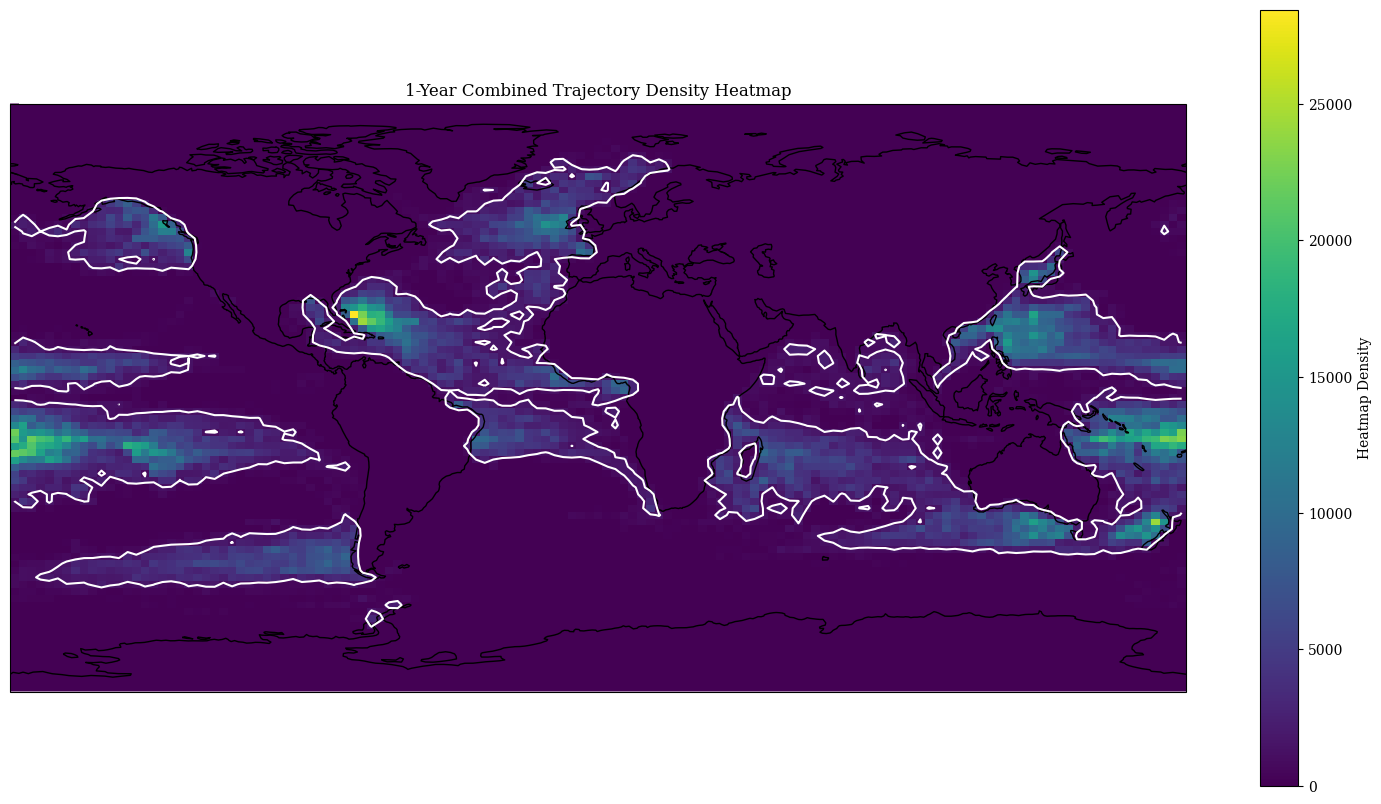

In [114]:
# Initialize the aggregated heatmap data
aggregated_heatmap_data = np.zeros((len(lat_bins) - 1, len(lon_bins) - 1))

# Create the figure and axis for plotting
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(15, 10))

# Loop through the dataframes and aggregate the heatmap data
for region, filepath in dataframes.items():
    # Read the CSV data for each region
    data = pd.read_csv(filepath)
    data = year_to_beach(data)  # Assuming this function exists
    data = preprocess_data(data)  # Assuming this function exists

    # Extract latitudes and longitudes
    latitudes = data['lat'].values
    longitudes = data['lon'].values

    # Create heatmap data for the current region
    heatmap_data, lat_bins, lon_bins = np.histogram2d(latitudes, longitudes, bins=[lat_bins, lon_bins], density=False)

    # Aggregate heatmap data
    aggregated_heatmap_data += heatmap_data

# Calculate the contour levels for the aggregated data
contour_levels = [np.percentile(aggregated_heatmap_data, 80)]  # Change percentile as needed for desired contours

lat_centers = (lat_bins[:-1] + lat_bins[1:]) / 2
lon_centers = (lon_bins[:-1] + lon_bins[1:]) / 2

# Plot the aggregated heatmap
mesh = ax.pcolormesh(lon_centers, lat_centers, aggregated_heatmap_data, cmap='viridis', transform=ccrs.PlateCarree())

# Plot a single contour (fused from all regions)
contour = ax.contour(lon_centers, lat_centers, aggregated_heatmap_data, levels=contour_levels, colors='white', linestyles='solid', transform=ccrs.PlateCarree())

# Set the title and plot coastlines
ax.set_title('1-Year Combined Trajectory Density Heatmap')
ax.coastlines()

# Add colorbar for the aggregated heatmap
plt.colorbar(mesh, ax=ax, orientation='vertical', shrink=0.8, label='Heatmap Density')

# Adjust layout and display the plot
plt.tight_layout()
plt.show()


In [115]:
# Assuming you have the ocean_area defined already, use it here
ocean_area = 361_132_000
print(f"Total Ocean Area: {ocean_area:.2f} sq km\n")

# Ocean area calculation for the trajectory contour
# Convert contour paths to polygons for area calculation
contour_paths = contour.collections[0].get_paths()
contour_polygons = []

for path in contour_paths:
    contour_polygons.append(Polygon(path.vertices))

# Create a GeoDataFrame for the contour area
contour_gdf = gpd.GeoDataFrame(geometry=contour_polygons, crs="EPSG:4326")

# Reproject contour to a projection that supports area calculation (e.g., EPSG:3395)
contour_gdf = contour_gdf.to_crs(epsg=3395)

# Calculate the area of the trajectory contour
trajectory_area = contour_gdf.geometry.area.sum() / 1_000_000  # Area in km²

# Ensure ocean_area is not zero to avoid division by zero
if ocean_area == 0:
    print("Error: The ocean area is zero. Check coastline data.")
else:
    # Calculate the percentage of ocean covered by the trajectory contour
    coverage_percentage = (trajectory_area / ocean_area) * 100

    # Calculate the difference in area
    area_difference = ocean_area - trajectory_area

    # Print the results
    print(f"Trajectory contour area: {trajectory_area:.2f} km²")
    print(f"Percentage of ocean covered by trajectory: {coverage_percentage:.2f}%")
    print(f"Difference in area: {area_difference:.2f} km²")

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

Total Ocean Area: 361132000.00 sq km



AttributeError: 'GeoContourSet' object has no attribute 'collections'

In [ ]:
# Initialize the aggregated heatmap data
aggregated_heatmap_data = np.zeros((len(lat_bins) - 1, len(lon_bins) - 1))

# Create the figure and axis for plotting
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(15, 10))

# Loop through the dataframes and aggregate the heatmap data
for region, filepath in dataframes.items():
    # Read the CSV data for each region
    data = pd.read_csv(filepath)
    data = six_to_beach(data)  # Assuming this function exists
    data = preprocess_data(data)  # Assuming this function exists

    # Extract latitudes and longitudes
    latitudes = data['lat'].values
    longitudes = data['lon'].values

    # Create heatmap data for the current region
    heatmap_data, lat_bins, lon_bins = np.histogram2d(latitudes, longitudes, bins=[lat_bins, lon_bins], density=False)

    # Aggregate heatmap data
    aggregated_heatmap_data += heatmap_data

# Calculate the contour levels for the aggregated data
contour_levels = [np.percentile(aggregated_heatmap_data, 80)]  # Change percentile as needed for desired contours

lat_centers = (lat_bins[:-1] + lat_bins[1:]) / 2
lon_centers = (lon_bins[:-1] + lon_bins[1:]) / 2

# Plot the aggregated heatmap
mesh = ax.pcolormesh(lon_centers, lat_centers, aggregated_heatmap_data, cmap='viridis', transform=ccrs.PlateCarree())

# Plot a single contour (fused from all regions)
contour = ax.contour(lon_centers, lat_centers, aggregated_heatmap_data, levels=contour_levels, colors='white', linestyles='solid', transform=ccrs.PlateCarree())

# Set the title and plot coastlines
ax.set_title('6m Combined Trajectory Density Heatmap')
ax.coastlines()

# Add colorbar for the aggregated heatmap
plt.colorbar(mesh, ax=ax, orientation='vertical', shrink=0.8, label='Heatmap Density')

# Adjust layout and display the plot
plt.tight_layout()
plt.show()
 

In [ ]:
# Assuming you have the ocean_area defined already, use it here
ocean_area = 361_132_000
print(f"Total Ocean Area: {ocean_area:.2f} sq km\n")

# Ocean area calculation for the trajectory contour
# Convert contour paths to polygons for area calculation
contour_paths = contour.collections[0].get_paths()
contour_polygons = []

for path in contour_paths:
    vertices = path.vertices
    # Check if there are enough vertices to form a polygon
    if len(vertices) >= 3:
        # Ensure the path is closed by repeating the first vertex at the end if needed
        if not (vertices[0] == vertices[-1]).all():
            vertices = np.vstack([vertices, vertices[0]])  # Close the path
        contour_polygons.append(Polygon(vertices))
    else:
        print("Skipping invalid contour path with less than 3 vertices")

# Create a GeoDataFrame for the contour area
contour_gdf = gpd.GeoDataFrame(geometry=contour_polygons, crs="EPSG:4326")

# Reproject contour to a projection that supports area calculation (e.g., EPSG:3395)
contour_gdf = contour_gdf.to_crs(epsg=3395)

# Calculate the area of the trajectory contour
trajectory_area = contour_gdf.geometry.area.sum() / 1_000_000  # Area in km²

# Ensure ocean_area is not zero to avoid division by zero
if ocean_area == 0:
    print("Error: The ocean area is zero. Check coastline data.")
else:
    # Calculate the percentage of ocean covered by the trajectory contour
    coverage_percentage = (trajectory_area / ocean_area) * 100

    # Calculate the difference in area
    area_difference = ocean_area - trajectory_area

    # Print the results
    print(f"Trajectory contour area: {trajectory_area:.2f} km²")
    print(f"Percentage of ocean covered by trajectory: {coverage_percentage:.2f}%")
    print(f"Difference in area: {area_difference:.2f} km²")

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

In [ ]:
# Initialize the aggregated heatmap data
aggregated_heatmap_data = np.zeros((len(lat_bins) - 1, len(lon_bins) - 1))

# Create the figure and axis for plotting
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(15, 10))

# Loop through the dataframes and aggregate the heatmap data
for region, filepath in dataframes.items():
    # Read the CSV data for each region
    data = pd.read_csv(filepath)
    data = three_to_beach(data)  # Assuming this function exists
    data = preprocess_data(data)  # Assuming this function exists

    # Extract latitudes and longitudes
    latitudes = data['lat'].values
    longitudes = data['lon'].values

    # Create heatmap data for the current region
    heatmap_data, lat_bins, lon_bins = np.histogram2d(latitudes, longitudes, bins=[lat_bins, lon_bins], density=False)

    # Aggregate heatmap data
    aggregated_heatmap_data += heatmap_data

# Calculate the contour levels for the aggregated data
contour_levels = [np.percentile(aggregated_heatmap_data, 80)]  # Change percentile as needed for desired contours

lat_centers = (lat_bins[:-1] + lat_bins[1:]) / 2
lon_centers = (lon_bins[:-1] + lon_bins[1:]) / 2

# Plot the aggregated heatmap
mesh = ax.pcolormesh(lon_centers, lat_centers, aggregated_heatmap_data, cmap='viridis', transform=ccrs.PlateCarree())

# Plot a single contour (fused from all regions)
contour = ax.contour(lon_centers, lat_centers, aggregated_heatmap_data, levels=contour_levels, colors='white', linestyles='solid', transform=ccrs.PlateCarree())

# Set the title and plot coastlines
ax.set_title('3m Combined Trajectory Density Heatmap')
ax.coastlines()

# Add colorbar for the aggregated heatmap
plt.colorbar(mesh, ax=ax, orientation='vertical', shrink=0.8, label='Heatmap Density')

# Adjust layout and display the plot
plt.tight_layout()
plt.show()
 

In [ ]:
# Initialize the aggregated heatmap data
aggregated_heatmap_data = np.zeros((len(lat_bins) - 1, len(lon_bins) - 1))

# Create the figure and axis for plotting
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(15, 10))

# Loop through the dataframes and aggregate the heatmap data
for region, filepath in dataframes.items():
    # Read the CSV data for each region
    data = pd.read_csv(filepath)
    data = one_to_beach(data)  # Assuming this function exists
    data = preprocess_data(data)  # Assuming this function exists

    # Extract latitudes and longitudes
    latitudes = data['lat'].values
    longitudes = data['lon'].values

    # Create heatmap data for the current region
    heatmap_data, lat_bins, lon_bins = np.histogram2d(latitudes, longitudes, bins=[lat_bins, lon_bins], density=False)

    # Aggregate heatmap data
    aggregated_heatmap_data += heatmap_data

# Calculate the contour levels for the aggregated data
contour_levels = [np.percentile(aggregated_heatmap_data, 80)]  # Change percentile as needed for desired contours

lat_centers = (lat_bins[:-1] + lat_bins[1:]) / 2
lon_centers = (lon_bins[:-1] + lon_bins[1:]) / 2

# Plot the aggregated heatmap
mesh = ax.pcolormesh(lon_centers, lat_centers, aggregated_heatmap_data, cmap='viridis', transform=ccrs.PlateCarree())

# Plot a single contour (fused from all regions)
contour = ax.contour(lon_centers, lat_centers, aggregated_heatmap_data, levels=contour_levels, colors='white', linestyles='solid', transform=ccrs.PlateCarree())

# Set the title and plot coastlines
ax.set_title('1m Combined Trajectory Density Heatmap')
ax.coastlines()

# Add colorbar for the aggregated heatmap
plt.colorbar(mesh, ax=ax, orientation='vertical', shrink=0.8, label='Heatmap Density')

# Adjust layout and display the plot
plt.tight_layout()
plt.show()
 

In [ ]:
# Assuming you have the ocean_area defined already, use it here
ocean_area = 361_132_000
print(f"Total Ocean Area: {ocean_area:.2f} sq km\n")

# Ocean area calculation for the trajectory contour
# Convert contour paths to polygons for area calculation
contour_paths = contour.collections[0].get_paths()
contour_polygons = []

for path in contour_paths:
    contour_polygons.append(Polygon(path.vertices))

# Create a GeoDataFrame for the contour area
contour_gdf = gpd.GeoDataFrame(geometry=contour_polygons, crs="EPSG:4326")

# Reproject contour to a projection that supports area calculation (e.g., EPSG:3395)
contour_gdf = contour_gdf.to_crs(epsg=3395)

# Calculate the area of the trajectory contour
trajectory_area = contour_gdf.geometry.area.sum() / 1_000_000  # Area in km²

# Ensure ocean_area is not zero to avoid division by zero
if ocean_area == 0:
    print("Error: The ocean area is zero. Check coastline data.")
else:
    # Calculate the percentage of ocean covered by the trajectory contour
    coverage_percentage = (trajectory_area / ocean_area) * 100

    # Calculate the difference in area
    area_difference = ocean_area - trajectory_area

    # Print the results
    print(f"Trajectory contour area: {trajectory_area:.2f} km²")
    print(f"Percentage of ocean covered by trajectory: {coverage_percentage:.2f}%")
    print(f"Difference in area: {area_difference:.2f} km²")

# Adjust layout and display the plot
plt.tight_layout()
plt.show()